# GNN Model Comparison on RNA Secondary Structure Data
**Author**: Elnaz Abbasifar  
**Supervisor**: Dr. Gajamannage  
**Date**: Dec 14, 2025  
**Version**: 3

**Objective:** This notebook explores and compares the performance of different Graph Neural Network (GNN) models for the classifying RNA secondary structure graphs.

**Dataset:** RNA secondary structure graphs (13 classes).

**Models Explored:**
*   Graph Isomorphism Network (GIN)
*   Graph Attention Network (GAT)
*   DiffPool (Hierarchical Pooling with GCN-based layers)

**Setup: install and import libraries**  

In [ ]:
!pip uninstall -y dgl torch torchdata torchaudio torchvision

Found existing installation: torch 2.9.0+cpu
Uninstalling torch-2.9.0+cpu:
  Successfully uninstalled torch-2.9.0+cpu
Found existing installation: torchdata 0.11.0
Uninstalling torchdata-0.11.0:
  Successfully uninstalled torchdata-0.11.0
Found existing installation: torchaudio 2.9.0+cpu
Uninstalling torchaudio-2.9.0+cpu:
  Successfully uninstalled torchaudio-2.9.0+cpu
Found existing installation: torchvision 0.24.0+cpu
Uninstalling torchvision-0.24.0+cpu:
  Successfully uninstalled torchvision-0.24.0+cpu


In [ ]:
# Install PyTorch Geometric
!pip install --quiet torch-geometric
!pip install --quiet torch torchvision torchaudio scikit-learn matplotlib optuna
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.

In [ ]:
# Clone the MANGO repository
!pip install git+https://github.com/ARM-software/mango.git

  Cloning https://github.com/ARM-software/mango.git to /tmp/pip-req-build-ome9adh0
  Running command git clone --filter=blob:none --quiet https://github.com/ARM-software/mango.git /tmp/pip-req-build-ome9adh0
  Resolved https://github.com/ARM-software/mango.git to commit 273552995170757ebe158e3d85a8b0e06912262a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for arm-mango: filename=arm_mango-1.5.1-py3-none-any.whl size=29374 sha256=6972dc805708fedffab238cd6b2afa62623b2a031db679352abe321ce7b96524
  Stored in directory: /tmp/pip-ephem-wheel-cache-w95x83wv/wheels/b0/9b/f0/a05a53ef403a7e6a9430410fffce8d049ca3c8afa19387c59e
Successfully built arm-mango


In [ ]:
# Clone the BANANAS repository
# !git clone https://github.com/naszilla/naszilla.git


In [ ]:
# # Return to the main naszilla directory
# %cd /content/naszilla

# # Check if setup.py is really here
# !ls

# # Now remove lines related to tensorflow, torch, and ConfigSpace
# !sed -i "/'tensorflow-gpu==1.14.0',/d" setup.py
# !sed -i "/'tensorflow==1.14.0',/d" setup.py
# !sed -i "/'torch==1.5.0',/d" setup.py
# !sed -i "/'torchvision==0.6.0',/d" setup.py
# !sed -i "/'ConfigSpace==0.4.12',/d" setup.py
# !sed -i "/'ConfigSpace==0.4.12',/d" setup.py

# # Explicitly install a compatible ConfigSpace dependency
# !pip install ConfigSpace

# # Install naszilla without TensorFlow, old Torch, and ConfigSpace (after removing dependencies)
# !pip install -e .

In [ ]:
# General imports
import os, pickle

# Data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import auc, accuracy_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix

# Graph imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.nn import DenseGCNConv, dense_diff_pool

import dgl
from dgl.dataloading import GraphDataLoader
from dgl.nn.pytorch import GINConv, GATConv, GraphConv #, DenseGraphConv

import random
import copy
from collections import deque, Counter

# Optimization imports
#from naszilla.nas_algorithms import bananas
from mango import scheduler, Tuner
from functools import partial
import itertools
from sklearn.neural_network import MLPRegressor

# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
Device: cpu


In [ ]:
print("PyTorch version:", torch.__version__)
print("DGL version:", dgl.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.4.0+cu121
DGL version: 2.4.0
CUDA available: False


In [ ]:
# current directory
!pwd

/content


In [ ]:
# link to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This notebook implements three GNN variants (GIN, GAT, DiffPool) for graph-level multi-class classification.  
Structure:
1. Data loading & preprocessing
2. DataLoaders
3. Model definitions (GIN, GAT, DiffPool)
4. Training loop and evaluation functions (AUC-ROC, AUC-PR, misclassification ratio)
5. Hyperparameter tuning
6. Run experiments (using best hyperparameters ) and compare results

### 1. Dataset preparation

**Load ncRNA Dataset**

In [ ]:
# Load provided pickle files and inspect a sample entry
data_dir = "/content/drive/MyDrive/Projects/RNA/data"
train_pkl = os.path.join(data_dir, "training6320_parent_list_type1.pkl")
test_pkl  = os.path.join(data_dir, "testing2600_parent_list_type1.pkl")

# Load files
with open(train_pkl, 'rb') as f:
    train_data = pickle.load(f)   # expected: list/array of dicts, each dict has keys 'parent_list' and 'label'

with open(test_pkl, 'rb') as f:
    test_data = pickle.load(f)

print("Train samples:", len(train_data))
print("Test samples :", len(test_data))

# Inspect a single entry
print("Example entry keys:", train_data[0].keys())
print("Example parent_list shape:", np.array(train_data[0]['parent_list']).shape)
print("Example label:", train_data[0]['label'])

Train samples: 6320
Test samples : 2600
Example entry keys: dict_keys(['parent_list', 'label'])
Example parent_list shape: (10, 2)
Example label: 5S_rRNA


# 🔍 Check 1: Exact Duplicate Graphs (Byte-Level Equality)

This section checks whether any two graphs have *identical* `parent_list`
(meaning the entire feature list is exactly the same at the byte level).

If any duplicated graphs exist **with different class labels**,
no machine-learning model can achieve high accuracy because the dataset contains
irreconcilable contradictions.

This check reports:
- Number of unique graphs  
- Number of duplicated parent_list entries  
- Whether duplicated graphs have conflicting labels  
- Examples of conflicting duplicates (if any)

In [ ]:
from collections import defaultdict
import json

def canonical_str_parent_list(parent_list):
    # represent parent_list as a stable json string (row-major)
    arr = np.array(parent_list, dtype=int)
    return json.dumps(arr.tolist())  # deterministic

def find_exact_duplicates(train_data, test_data=None, max_examples=5):
    # build map: canonical_str -> list of (source, idx, label)
    # source: 'train' or 'test'
    mapping = defaultdict(list)
    for i, d in enumerate(train_data):
        key = canonical_str_parent_list(d['parent_list'])
        mapping[key].append(('train', i, d['label']))
    if test_data is not None:
        for i, d in enumerate(test_data):
            key = canonical_str_parent_list(d['parent_list'])
            mapping[key].append(('test', i, d['label']))

    # detect keys with >1 occurrence
    dup_items = {k: v for k, v in mapping.items() if len(v) > 1}
    print(f"Total unique canonical graphs: {len(mapping)}")
    print(f"Exact duplicate groups (count>1): {len(dup_items)}")

    # Find groups that have >1 label (conflicting labels)
    conflicts = {}
    for k, records in dup_items.items():
        labels = set(r[2] for r in records)
        if len(labels) > 1:
            conflicts[k] = records

    print(f"Exact duplicate groups with conflicting labels: {len(conflicts)}")

    # Summary table
    rows = []
    for k, records in dup_items.items():
        n = len(records)
        lbls = sorted(list({r[2] for r in records}))
        rows.append({'key': k, 'count': n, 'labels': lbls, 'examples': records[:max_examples]})
    df = pd.DataFrame(rows).sort_values('count', ascending=False)
    return mapping, dup_items, conflicts, df

# Usage (put this right after loading train_data/test_data)
mapping, dup_items, conflicts, dup_table = find_exact_duplicates(train_data, test_data)
print(dup_table.head(20))
# If conflicts non-empty, show an example
if len(conflicts) > 0:
    k, recs = next(iter(conflicts.items()))
    print("Example conflicting group (records):")
    for rec in recs:
        print(rec)

Total unique canonical graphs: 3866
Exact duplicate groups (count>1): 792
Exact duplicate groups with conflicting labels: 536
                                                   key  count  \
221  [[0, 5], [1, 6], [2, 1], [3, 2], [4, 3], [5, 4...    218   
318  [[0, 4], [1, 5], [2, 1], [3, 2], [4, 3], [5, -1]]    191   
356  [[0, 2], [1, 4], [2, 5], [3, 5], [4, 3], [5, -1]]    174   
83   [[0, 6], [1, 7], [2, 1], [3, 2], [4, 3], [5, 4...    164   
213          [[0, 3], [1, 4], [2, 1], [3, 2], [4, -1]]    148   
368          [[0, 2], [1, 3], [2, 4], [3, 4], [4, -1]]    138   
364  [[0, 2], [1, 5], [2, 6], [3, 6], [4, 3], [5, 4...    131   
322          [[0, 3], [1, 3], [2, 3], [3, 4], [4, -1]]    131   
342                  [[0, 2], [1, 3], [2, 1], [3, -1]]    112   
64   [[0, 7], [1, 8], [2, 1], [3, 2], [4, 3], [5, 4...    108   
140  [[0, 2], [1, 6], [2, 7], [3, 7], [4, 3], [5, 4...     99   
360  [[0, 3], [1, 5], [2, 6], [3, 2], [4, 6], [5, 4...     79   
17   [[0, 8], [1, 9], [2, 1],

# 🔍 Check 2: Inspect Conflicting Exact Duplicates

If Check 1 detects graphs that are byte-level identical but assigned to
different classes, this section prints sample cases.

These conflicting duplicates are critical issues that directly cap model performance.


In [ ]:
print("Number of exact-conflict groups:", len(conflicts))
# list conflicting labels counts
for k, recs in list(conflicts.items())[:10]:
    print("Group occurrences:", len(recs))
    for src, idx, lbl in recs:
        print(f"  {src} idx={idx} label={lbl}")
    print("---")

Number of exact-conflict groups: 536
Group occurrences: 10
  train idx=0 label=5S_rRNA
  train idx=1 label=5S_rRNA
  train idx=11 label=5S_rRNA
  train idx=129 label=5S_rRNA
  train idx=267 label=5S_rRNA
  train idx=457 label=5S_rRNA
  train idx=5853 label=HACA-box
  test idx=25 label=5S_rRNA
  test idx=26 label=5S_rRNA
  test idx=2435 label=HACA-box
---
Group occurrences: 17
  train idx=3 label=5S_rRNA
  train idx=9 label=5S_rRNA
  train idx=16 label=5S_rRNA
  train idx=53 label=5S_rRNA
  train idx=57 label=5S_rRNA
  train idx=97 label=5S_rRNA
  train idx=147 label=5S_rRNA
  train idx=179 label=5S_rRNA
  train idx=295 label=5S_rRNA
  train idx=320 label=5S_rRNA
  train idx=362 label=5S_rRNA
  train idx=392 label=5S_rRNA
  train idx=4362 label=HACA-box
  train idx=4582 label=riboswitch
  test idx=6 label=5S_rRNA
  test idx=11 label=5S_rRNA
  test idx=19 label=5S_rRNA
---
Group occurrences: 15
  train idx=5 label=5S_rRNA
  train idx=10 label=5S_rRNA
  train idx=26 label=5S_rRNA
  train 

# 🔍 Check 3: Graph Isomorphism Check (Structure-Level Duplicates)

In this section, we check whether any two graphs are *structurally identical*
(isomorphic) even if their node indexing differs.

If structurally identical graphs have different labels, then:
- The dataset contains inherent contradictions  
- No amount of hyperparameter tuning can improve accuracy  
- The issue is likely due to labeling or preprocessing errors

This check uses NetworkX and hashing/fingerprinting to keep computation efficient.

In [ ]:
import networkx as nx
from tqdm import tqdm
from collections import defaultdict

def parent_list_to_nx(parent_list):
    arr = np.array(parent_list, dtype=int)
    G = nx.Graph()
    if arr.size == 0:
        return G
    N = arr.shape[0]
    G.add_nodes_from(range(N))
    for u,p in arr:
        u=int(u); p=int(p)
        if p == -1: continue
        G.add_edge(u,p)
    return G

def graph_invariants(parent_list):
    arr = np.array(parent_list, dtype=int)
    N = arr.shape[0]
    G = parent_list_to_nx(arr)
    degs = sorted([d for _, d in G.degree()])
    # depth vector as computed earlier
    # compute roots and BFS depths:
    parent = {int(r[0]): int(r[1]) for r in arr}
    children = {i: [] for i in range(N)}
    roots=[]
    for node,p in parent.items():
        if p==-1:
            roots.append(node)
        else:
            children[p].append(node)
    # compute depths
    depth = [0]*N
    from collections import deque
    q = deque([(r,0) for r in roots]) if roots else deque([(0,0)])
    visited = set()
    while q:
        u,d = q.popleft()
        if u in visited: continue
        visited.add(u)
        depth[u]=d
        for v in children.get(u,[]):
            q.append((v,d+1))
    return {"N":N, "deg_hist":tuple(degs), "depth_hist":tuple(sorted(depth))}

# group by invariants
def find_isomorphic_conflicts(data_list):
    # data_list: list of dicts with 'parent_list' and 'label' and maybe index info
    inv_map = defaultdict(list)
    for i,d in enumerate(data_list):
        inv = graph_invariants(d['parent_list'])
        key = (inv['N'], inv['deg_hist'], inv['depth_hist'])
        inv_map[key].append(i)
    # Inspect groups with >1 member
    pairs_conflicts = []
    checked = set()
    for k, idxs in list(inv_map.items()):
        if len(idxs) <= 1: continue
        # pairwise compare inside group using isomorphism
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                a = idxs[i]; b = idxs[j]
                if (a,b) in checked: continue
                Ga = parent_list_to_nx(data_list[a]['parent_list'])
                Gb = parent_list_to_nx(data_list[b]['parent_list'])
                gm = nx.algorithms.isomorphism.GraphMatcher(Ga, Gb)
                iso = gm.is_isomorphic()
                if iso:
                    if data_list[a]['label'] != data_list[b]['label']:
                        pairs_conflicts.append((a,b, data_list[a]['label'], data_list[b]['label']))
                checked.add((a,b))
    return pairs_conflicts


conflicting_isomorphic_pairs = find_isomorphic_conflicts(train_data + test_data)

print(f"Number of conflicting isomorphic pairs: {len(conflicting_isomorphic_pairs)}")
print("Sample conflicts:", conflicting_isomorphic_pairs[:10])

Number of conflicting isomorphic pairs: 131916
Sample conflicts: [(0, 5853, '5S_rRNA', 'HACA-box'), (0, 8755, '5S_rRNA', 'HACA-box'), (1, 5853, '5S_rRNA', 'HACA-box'), (1, 8755, '5S_rRNA', 'HACA-box'), (11, 5853, '5S_rRNA', 'HACA-box'), (11, 8755, '5S_rRNA', 'HACA-box'), (129, 5853, '5S_rRNA', 'HACA-box'), (129, 8755, '5S_rRNA', 'HACA-box'), (267, 5853, '5S_rRNA', 'HACA-box'), (267, 8755, '5S_rRNA', 'HACA-box')]


In [ ]:
def plot_dataset_summary(num_unique, num_exact_groups, num_conflict_groups, num_iso_conflicts):
    """
    Plot a simple bar chart summarizing dataset structure issues:
    - unique canonical structures
    - exact duplicate groups
    - exact duplicate groups with conflicting labels
    - isomorphic conflicts
    """

    labels = [
        "Unique\nStructures",
        "Exact Duplicate\nGroups",
        "Conflicting\nExact Groups",
        "Isomorphic\nConflicts"
    ]

    values = [
        num_unique,
        num_exact_groups,
        num_conflict_groups,
        num_iso_conflicts
    ]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values)

    # Add value annotations
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval + (0.02 * yval),
            str(yval),
            ha='center',
            va='bottom',
            fontsize=11
        )

    plt.title("Dataset Structural Summary Before Cleaning", fontsize=14)
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

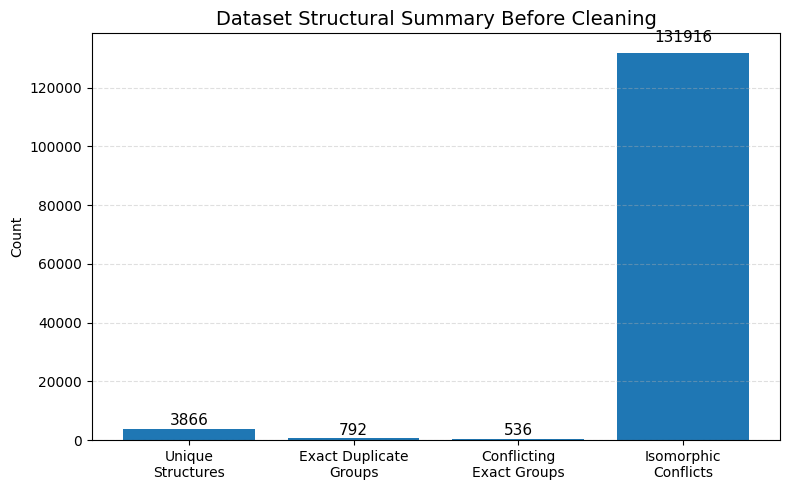

In [ ]:
plot_dataset_summary(
    num_unique=len(mapping),
    num_exact_groups=len(dup_items),
    num_conflict_groups=len(conflicts),
    num_iso_conflicts=len(conflicting_isomorphic_pairs)
)

## Cleaning the Dataset (Exact + Isomorphic Removal)
We remove all exact duplicates and all isomorphic duplicates.
We keep only one instance overall per structural group (the first occurrence) and discard all remaining copies.

### Advanced Graph Cleaning with Weisfeiler-Lehman Isomorphism Test

This section performs a robust and comprehensive cleaning of the dataset by identifying and removing truly isomorphic (structurally identical) graphs. This method utilizes the **Weisfeiler-Lehman (WL) graph hashing algorithm**.

**Why Weisfeiler-Lehman?**
- **Graph Isomorphism:** Two graphs are isomorphic if they have the same structure, even if their nodes are numbered differently. The WL algorithm is a powerful heuristic for distinguishing non-isomorphic graphs and often identifies isomorphic graphs by assigning them the same canonical hash.
- **Deeper Structural Cleaning:** This method ensures that the dataset contains only unique structural patterns, preventing models from learning redundant information or being confused by conflicting labels on identical structures. This is particularly crucial for GNNs, which are sensitive to graph topology.

**Impact:**
By using the WL test, a larger number of 'duplicates' might be identified and removed compared to simpler methods, as it captures structural equivalences that were previously missed. This leads to a more refined and reliable dataset for training, despite potentially reducing the overall sample count more significantly.

In [ ]:
# ============================
#   FINAL DATA CLEANING STEP
#   (Exact duplicates + Isomorphic)
#   Keep ONLY ONE instance total
# ============================

print("=== Starting Final Cleaning (exact + isomorphic) ===")
# ---------------------------------------------
# 1) Canonical form helper
# ---------------------------------------------
def canonical_form(parent_list):
    edges = [(int(a), int(b)) for a, b in parent_list if b != -1]
    G = nx.Graph()
    G.add_edges_from(edges)
    mapping = {n: i for i, n in enumerate(sorted(G.nodes()))}
    G = nx.relabel_nodes(G, mapping)
    return nx.weisfeiler_lehman_graph_hash(G, iterations=3)

# ---------------------------------------------
# 2) Build canonical keys for whole dataset
# ---------------------------------------------
def build_canonical_map(dataset):
    canonical_map = defaultdict(list)
    for idx, entry in enumerate(dataset):
        key = canonical_form(entry["parent_list"])
        canonical_map[key].append((idx, entry["label"]))
    return canonical_map

# ---------------------------------------------
# 3) Clean dataset => keep only *one overall instance*
# ---------------------------------------------
def clean_dataset_keep_first(dataset):
    canonical_map = build_canonical_map(dataset)

    kept_indices = set()
    removed_indices = set()

    # global first-appearance keeper
    for key, group in canonical_map.items():
        group_sorted = sorted(group, key=lambda x: x[0])  # sort by original index
        keep_idx = group_sorted[0][0]                    # keep only the FIRST instance
        kept_indices.add(keep_idx)

        # all remaining are removed
        for idx, _ in group_sorted[1:]: # Use underscore for unused variable
            removed_indices.add(idx)

    # build cleaned dataset
    cleaned = [dataset[i] for i in sorted(list(kept_indices))]
    return cleaned, canonical_map, kept_indices, removed_indices

# ---------------------------------------------
# 4) Class distribution helper
# ---------------------------------------------
def class_distribution(dataset):
    labels = [e["label"] for e in dataset]
    return Counter(labels)

# ---------------------------------------------
# 5) Summary before/after cleaning
# ---------------------------------------------
def summarize_cleaning(original_train_data, original_test_data):
    # Combine original data to track origin
    full_original_data = original_train_data + original_test_data
    original_train_len = len(original_train_data)

    # BEFORE CLEANING
    before_dist = class_distribution(full_original_data)
    before_total = len(full_original_data)

    # CLEAN using the advanced method
    cleaned_combined_data, canonical_map, kept_indices, removed_indices = clean_dataset_keep_first(full_original_data)

    # Split cleaned data back into train and test based on original origin
    cleaned_train_data_final = []
    cleaned_test_data_final = []

    # Create a list of all entries from original train and test, with their original index
    # to correctly map after cleaning.
    current_all_entries = original_train_data + original_test_data
    # The 'kept_indices' are indices relative to 'current_all_entries'

    for original_idx in sorted(list(kept_indices)):
        entry = current_all_entries[original_idx]
        if original_idx < original_train_len:
            cleaned_train_data_final.append(entry)
        else:
            cleaned_test_data_final.append(entry)

    # AFTER CLEANING
    after_dist = class_distribution(cleaned_combined_data)
    after_total = len(cleaned_combined_data)

    summary = {
        "before_total": before_total,
        "before_class_distribution": before_dist,
        "after_total": after_total,
        "after_class_distribution": after_dist,
        "removed_count": len(removed_indices),
        "unique_structures": len(canonical_map),
        "imbalance_before": {k: v / before_total for k, v in before_dist.items()},
        "imbalance_after": {k: v / after_total for k, v in after_dist.items()},
        "sample_conflict_groups": [
            (key, group) for key, group in list(canonical_map.items())[:5]
            if len(set([lab for _, lab in group])) > 1
        ]
    }

    return cleaned_combined_data, cleaned_train_data_final, cleaned_test_data_final, summary

# ---------------------------------------------
# 6) Run
# ---------------------------------------------
# Pass the *original* train_data and test_data to the cleaning function
cleaned_dataset_combined, cleaned_train_data, cleaned_test_data, cleaning_summary = summarize_cleaning(train_data, test_data)

# Update global train_data and test_data with the results from this cleaning process
global train_data, test_data
train_data = cleaned_train_data
test_data = cleaned_test_data

print("===== DATASET CLEANING SUMMARY ====")
print("Total samples BEFORE cleaning:", cleaning_summary["before_total"])
print("Class distribution BEFORE:", cleaning_summary["before_class_distribution"])
print("Imbalance BEFORE:", cleaning_summary["imbalance_before"])
print("-------------------------------------")
print("Total samples AFTER cleaning:", cleaning_summary["after_total"])
print("Class distribution AFTER:", cleaning_summary["after_class_distribution"])
print("Imbalance AFTER:", cleaning_summary["imbalance_after"])
print("-------------------------------------")
print("Unique structures:", cleaning_summary["unique_structures"])
print("Removed samples:", cleaning_summary["removed_count"])
print("-------------------------------------")
print("Sample conflicting groups (first 5):")
for key, group in cleaning_summary["sample_conflict_groups"]:
    print(key, group)

print(f"\nGlobal 'train_data' updated to size: {len(train_data)}")
print(f"Global 'test_data' updated to size: {len(test_data)}")


=== Starting Final Cleaning (exact + isomorphic) ===
===== DATASET CLEANING SUMMARY ====
Total samples BEFORE cleaning: 2271
Class distribution BEFORE: Counter({'Intron_gpI': 655, 'ribozyme': 460, '5_8S_rRNA': 267, 'IRES': 264, 'riboswitch': 176, 'scaRNA': 163, '5S_rRNA': 125, 'CD-box': 51, 'HACA-box': 44, 'leader': 29, 'Intron_gpII': 15, 'miRNA': 14, 'tRNA': 8})
Imbalance BEFORE: {'5S_rRNA': 0.055041831792162044, '5_8S_rRNA': 0.11756935270805813, 'tRNA': 0.0035226772346983706, 'ribozyme': 0.2025539409951563, 'CD-box': 0.022457067371202115, 'Intron_gpI': 0.2884191985909291, 'Intron_gpII': 0.0066050198150594455, 'HACA-box': 0.019374724790841038, 'riboswitch': 0.07749889916336415, 'IRES': 0.11624834874504623, 'leader': 0.012769704975781594, 'scaRNA': 0.0717745486569793, 'miRNA': 0.006164685160722149}
-------------------------------------
Total samples AFTER cleaning: 2271
Class distribution AFTER: Counter({'Intron_gpI': 655, 'ribozyme': 460, '5_8S_rRNA': 267, 'IRES': 264, 'riboswitch': 1

### Class Distribution Before/After Cleaning

We compare class frequencies before and after cleaning to see if the dataset becomes more imbalanced.

=== Class Distribution Before Cleaning ===
5S_rRNA        700
5_8S_rRNA      700
tRNA           700
ribozyme       700
CD-box         700
miRNA          700
Intron_gpI     700
Intron_gpII    700
HACA-box       700
riboswitch     700
IRES           520
leader         700
scaRNA         700
dtype: int64

=== Class Distribution After Cleaning ===
5S_rRNA        125
5_8S_rRNA      267
tRNA             8
ribozyme       460
CD-box          51
Intron_gpI     655
Intron_gpII     15
HACA-box        44
riboswitch     176
IRES           264
leader          29
scaRNA         163
miRNA           14
dtype: int64


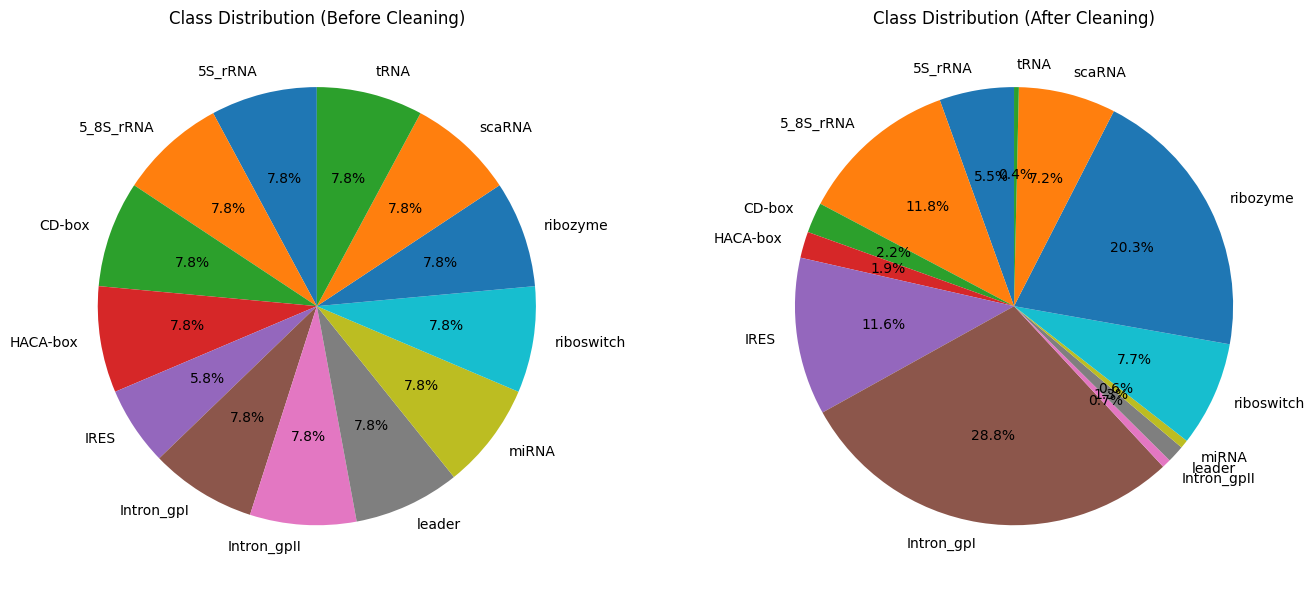

In [ ]:
# distribution before
dist_before = cleaning_summary["before_class_distribution"]

# distribution after
dist_after = cleaning_summary["after_class_distribution"]

print("=== Class Distribution Before Cleaning ===")
# Convert Counter to Series for consistent display with value_counts()
print(pd.Series(dist_before))
print("\n=== Class Distribution After Cleaning ===")
print(pd.Series(dist_after))

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before
# For pie chart, sort by index for consistent slice ordering, then get values and labels
labels_before = sorted(dist_before.keys())
values_before = [dist_before[label] for label in labels_before]
axes[0].pie(values_before, labels=labels_before, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Class Distribution (Before Cleaning)")

# After
labels_after = sorted(dist_after.keys())
values_after = [dist_after[label] for label in labels_after]
axes[1].pie(values_after, labels=labels_after, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Class Distribution (After Cleaning)")

plt.tight_layout()
plt.show()


**Preprocess data**

In [ ]:
# Combine labels from train and test data
all_labels = [d['label'] for d in train_data] + [d['label'] for d in test_data]
le = LabelEncoder()
le.fit(all_labels)

# Create a consistent label-to-index mapping (sorted alphabetically for reproducibility)
#label_encoder = {lbl: idx for idx, lbl in enumerate(sorted(set(all_labels)))} # This was commented out in original
#label_decoder = {v: k for k, v in label_encoder.items()} # This was commented out in original

# Number of classes
num_classes = len(le.classes_)
# List of class names
class_names = list(le.classes_)
print("Number of classes:", num_classes)
print("Class names:", class_names)


Number of classes: 13
Class names: [np.str_('5S_rRNA'), np.str_('5_8S_rRNA'), np.str_('CD-box'), np.str_('HACA-box'), np.str_('IRES'), np.str_('Intron_gpI'), np.str_('Intron_gpII'), np.str_('leader'), np.str_('miRNA'), np.str_('riboswitch'), np.str_('ribozyme'), np.str_('scaRNA'), np.str_('tRNA')]


## Class-balanced loss for imbalanced graph classification

After removing duplicate and isomorphic structures, the dataset becomes highly imbalanced across ncRNA classes.
To address this issue without generating synthetic graphs, we apply a **class-balanced loss by weighting the cross-entropy loss** inversely proportional to class frequencies, following imbalance-aware GNN literature.

In [ ]:
from collections import Counter
import torch
import numpy as np

def compute_class_weights(train_data, label_encoder, device):
    """
    Compute inverse-frequency class weights from training data only.
    """
    labels = [entry['label'] for entry in train_data]
    counts = Counter(labels)

    num_classes = len(label_encoder.classes_)
    weights = np.zeros(num_classes, dtype=np.float32)

    for label, count in counts.items():
        idx = label_encoder.transform([label])[0]
        weights[idx] = 1.0 / count

    # normalize (optional but recommended)
    weights = weights / weights.sum() * num_classes

    return torch.tensor(weights, dtype=torch.float32).to(device)


In [ ]:
class_weights = compute_class_weights(train_data, le, device)

### Node and Edge Feature Engineering

**Integrating one-hot encodings for nucleotide types into node features**  
First, I need to define the one-hot encoding map for nucleotides. Since the original dataset does not contain nucleotide sequences, I will generate dummy random sequences for each node in each graph entry for both training and testing datasets. This will enable the subsequent modification of the graph conversion function.


In [ ]:
import random

# 1. Define the one-hot encoding map for nucleotides (A, U, C, G)
NUCLEOTIDE_MAP = {
    'A': [1, 0, 0, 0],
    'U': [0, 1, 0, 0],
    'C': [0, 0, 1, 0],
    'G': [0, 0, 0, 1]
}
nucleotides_list = ['A', 'U', 'C', 'G']

# 2. Add dummy 'nucleotide_sequence' to each entry in train_data and test_data
# This simulates the presence of nucleotide information which is not in the original pickle files.
for entry in train_data:
    num_nodes = np.array(entry['parent_list']).shape[0]
    # Generate a random nucleotide sequence for each node
    entry['nucleotide_sequence'] = [random.choice(nucleotides_list) for _ in range(num_nodes)]

for entry in test_data:
    num_nodes = np.array(entry['parent_list']).shape[0]
    entry['nucleotide_sequence'] = [random.choice(nucleotides_list) for _ in range(num_nodes)]

print("Nucleotide one-hot mapping defined and dummy nucleotide sequences added to data entries.")

Nucleotide one-hot mapping defined and dummy nucleotide sequences added to data entries.


**Convert raw `parent_list` dictionaries to DGL graphs**  
- `dict_entry_to_dglgraph` function builds an undirected DGL graph from the parent_list. node features store in `g.ndata['feat']` (repeated per node for convenience).

- `compute_tree_node_features` function computes structural node features (degree, normalized depth, subtree size, is_leaf, num_children).

In [ ]:
# Helper functions to convert parent_list -> DGLGraph
def parent_list_to_edges(parent_list):
    """
    parent_list: numpy array of shape (N,2) with rows [node_idx, parent_idx]
    where col0=node_idx, col1=parent_idx (-1 for root)
    Returns src_list, dst_list for undirected edges (we add both directions). We'll use undirected edges for GNN.
    """
    edges_src = [] # a list of source of an edge
    edges_dst = [] # a list of destination of an edge
    for row in parent_list:
        u = int(row[0]) # node
        p = int(row[1]) # parent
        if p == -1:
            continue
        # add bidirectional edges (undirected)
        edges_src.extend([u, p])
        edges_dst.extend([p, u])
    return edges_src, edges_dst

# We create structural features because the provided entries contain topology only.
def compute_tree_node_features(parent_list):
    """
    Compute simple node-level features for each node in the tree:
    - degree (undirected)
    - depth from root (root depth=0)
    - subtree size (number of descendants)
    Returns: numpy array shape (N, 3), dtype float32
    """
    parent_list = np.array(parent_list, dtype=int)
    n_nodes = int(parent_list[:,0].max()) + 1 if parent_list.size > 0 else 0

    N = parent_list.shape[0]
    parent = {int(r[0]): int(r[1]) for r in parent_list}
    children = {i: [] for i in range(N)}
    children_count = np.zeros(n_nodes, dtype=int)
    roots = []
    for node, p in parent.items():
        if p == -1:
            roots.append(node)
        else:
            children[p].append(node)
            children_count[p] += 1

    # Structural features
    # degree (undirected)
    deg = np.zeros(N, dtype=np.float32)
    for u in range(N):
        d = len(children[u])
        if parent[u] != -1:
            d += 1
        deg[u] = d
    is_leaf = (children_count == 0).astype(float)
    num_children = children_count.astype(float)

    # depth(s): BFS from each root (handle forest)
    depth = np.zeros(N, dtype=np.float32)
    if len(roots) == 0:
        roots = [0]  # fallback
    visited = set()
    q = deque()
    for r in roots:
        q.append((r, 0))
        visited.add(r)
    while q:
        u, d = q.popleft()
        depth[u] = d
        for v in children[u]:
            if v not in visited:
                visited.add(v)
                q.append((v, d+1))

    # subtree sizes using post-order DFS (handle forest)
    subtree = np.zeros(N, dtype=np.float32)
    def compute_subtree(u):
        s = 1
        for v in children[u]:
            s += compute_subtree(v)
        subtree[u] = s
        return s
    for r in roots:
        compute_subtree(r)

    # normalize depth and subtree to [0,1]
    if depth.max() > 0:
        depth_norm = depth / (depth.max() + 1e-12)
    else:
        depth_norm = depth
    if subtree.max() > 0:
        subtree_norm = subtree / (subtree.max() + 1e-12)
    else:
        subtree_norm = subtree

    feats = np.stack([deg, depth_norm, subtree_norm, is_leaf, num_children], axis=1).astype(np.float32)
    return feats

def dict_entry_to_dglgraph(entry):
    """
    Convert a dictionary entry {'parent_list':..., 'label':...} to (dgl_graph, label).
    Node features are structural features computed above and stored as 'feat'.
    entry: dict with keys 'parent_list' (np.array Nx2) and 'label'
    returns: DGLGraph with g.ndata['feat'] (torch.float32) and g.ndata['label']
    """
    parent_list = np.array(entry['parent_list'], dtype=int)

    # assume parent_list rows are [node_idx, parent_idx]
    src, dst = parent_list_to_edges(parent_list)

    # create graph with N nodes
    n_nodes = parent_list.shape[0]
    if len(src) == 0:
        # isolated single-node tree
        g = dgl.graph(([], []), num_nodes=n_nodes)
    else:
        g = dgl.graph((src, dst), num_nodes=n_nodes)

    # create structural node features
    structural_feats = compute_tree_node_features(parent_list)

    # NEW: incorporate one-hot encoded nucleotide features
    nucleotide_sequence = entry['nucleotide_sequence']
    one_hot_feats = []
    for nucleotide in nucleotide_sequence:
        one_hot_feats.append(NUCLEOTIDE_MAP[nucleotide])
    one_hot_feats = np.array(one_hot_feats, dtype=np.float32)

    # Concatenate structural and one-hot features
    combined_feats = np.concatenate((structural_feats, one_hot_feats), axis=1)

    g.ndata['feat'] = torch.tensor(combined_feats)

    # Use global LabelEncoder 'le'
    label_idx = le.transform([entry['label']])[0]
    g.graph_label = torch.tensor([label_idx], dtype=torch.long)

    return g


**Convert data to graphs**

In [ ]:
# convert train_data to graphs and labels listss
train_graphs = [dict_entry_to_dglgraph(e) for e in train_data]
train_labels_int = le.transform([e['label'] for e in train_data])   # shape (N,)
# convert test_data to graphs and labels lists
test_graphs  = [dict_entry_to_dglgraph(e) for e in test_data]
test_labels_int  = le.transform([e['label'] for e in test_data])

print('Train graphs:', len(train_graphs), 'Test graphs:', len(test_graphs))
print("Example nodes in graph[0]", train_graphs[0].num_nodes(), "feat shape", train_graphs[0].ndata['feat'].shape)

Train graphs: 1842 Test graphs: 429
Example nodes in graph[0] 10 feat shape torch.Size([10, 9])


**Normalize node features**

In [ ]:
# 1) Compute mean/std from TRAIN graphs ONLY
all_feats = torch.cat([g.ndata['feat'] for g in train_graphs], dim=0)
mean = all_feats.mean(0)
std  = all_feats.std(0) + 1e-6

# 2) Apply on TRAIN
for g in train_graphs:
    g.ndata['feat'] = (g.ndata['feat'] - mean) / std

# 3) Apply SAME normalization on TEST
for g in test_graphs:
    g.ndata['feat'] = (g.ndata['feat'] - mean) / std

# Verify the updated input feature dimension
in_feats = train_graphs[0].ndata['feat'].shape[1]
print(f"New input feature dimension (in_feats): {in_feats}")

New input feature dimension (in_feats): 9


**Class distribution**

Train class counts:
  class 0: 121
  class 1: 222
  class 2: 40
  class 3: 37
  class 4: 187
  class 5: 487
  class 6: 13
  class 7: 22
  class 8: 12
  class 9: 141
  class 10: 405
  class 11: 147
  class 12: 8
Test class counts:
  class 0: 4
  class 1: 45
  class 2: 11
  class 3: 7
  class 4: 77
  class 5: 168
  class 6: 2
  class 7: 7
  class 8: 2
  class 9: 35
  class 10: 55
  class 11: 16


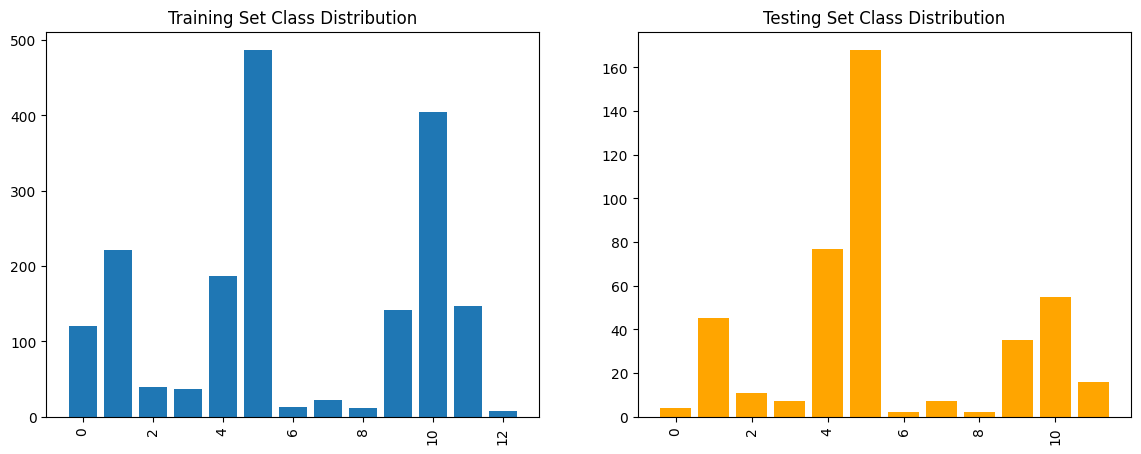

In [ ]:
# Check class distribution
def extract_graph_label(g):
    # The graph label is stored in g.graph_label
    if hasattr(g, 'graph_label') and g.graph_label is not None and len(g.graph_label) > 0:
        return int(g.graph_label.item())
    else:
        # If no graph label is found (e.g., for a graph with no nodes), handle appropriately
        # For this dataset, all graphs should have a label, but we add a check.
        # Returning -1 or raising an error depends on how you want to handle such cases.
        # Since all graphs in this dataset should have labels, raising an error is reasonable.
        raise RuntimeError('Graph label not found in g.graph_label.')

train_labels = [extract_graph_label(g) for g in train_graphs]
test_labels  = [extract_graph_label(g) for g in test_graphs]
unique, counts = np.unique(train_labels, return_counts=True)
print('Train class counts:')
for u,c in zip(unique, counts):
    print(f'  class {u}: {c}')
unique_t, counts_t = np.unique(test_labels, return_counts=True)
print('Test class counts:')
for u,c in zip(unique_t, counts_t):
    print(f'  class {u}: {c}')

# --- Visualization ---
train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values())
axes[0].set_title("Training Set Class Distribution")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(test_counts.keys(), test_counts.values(), color='orange')
axes[1].set_title("Testing Set Class Distribution")
axes[1].tick_params(axis='x', rotation=90)

plt.show()

The dataset is generally well-balanced across classes. Most classes in the training set have 500 samples, while class 4 has slightly fewer (320 samples), indicating a minor imbalance.  
The test set is perfectly balanced, with 200 samples for each class.  
Overall, the data distribution is nearly uniform, with only a small deviation for class 4.

### 2. DataLoaders

**Define DataLoaders**

In [ ]:
from torch.utils.data import random_split

class ListGraphDataset(Dataset):
    def __init__(self, graphs, labels):
        assert len(graphs) == len(labels)
        self.graphs = graphs
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]

# Create dataset objects
train_dataset = ListGraphDataset(train_graphs, train_labels_int)
test_dataset  = ListGraphDataset(test_graphs, test_labels_int)

# create internal split (85/15)
N = len(train_dataset)
n_val = int(0.15 * N)
n_train = N - n_val
gen = torch.Generator().manual_seed(seed)
train_subset, val_subset = random_split(train_dataset, [n_train, n_val], generator=gen)

# Basic dataloaders (batch size to be tuned later)
# DataLoaders: each batch yields (batched_graphs, labels_tensor)
batch_size = 32
train_loader = GraphDataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader   = GraphDataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader  = GraphDataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_subset), "Val size:", len(val_subset), "Test size:", len(test_dataset))


Train size: 1566 Val size: 276 Test size: 429


### 3. Model definitions

**Define models (GIN, GAT, DiffPool)**

Three GNN variants with increasing architectural complexity and representational power are defined:

- **GIN (Graph Isomorphism Network)**  
  A strong baseline with MLP-based aggregation due to its high discriminative capacity for graph structures.  
  GIN captures subtle differences in topology, making it particularly suitable for structured biological data such as RNA secondary trees.

- **GAT (Graph Attention Network)**  
  Extends GIN by introducing attention mechanisms, allowing the model to assign different weights to neighboring nodes to learn which neighboring nodes are more informative.  
  This selective aggregation improves performance in heterogeneous or irregular graph structures.

- **DiffPool (Differentiable Pooling Network)**  
  Adds a hierarchical pooling layer that clusters nodes during learning. This is especially useful for capturing multi-level or modular organization in RNA secondary structures.

This sequence — **GIN → GAT → DiffPool** — provides a logical progression from simple neighborhood aggregation, to adaptive attention mechanisms, and finally to hierarchical graph abstraction.  
It allows for a deeper understanding of how structural modeling complexity impacts ncRNA classification performance.


**Update**: We need to modify the GINNet, GATNet, and GCNNet classes to accept an **aggregation parameter** during initialization and use it to select between **sum** or **mean** aggregation in their forward methods. This will involve **updating** the `__init__` and `forward` methods of each of these classes. The DiffPoolNet definition does not need to be changed as its aggregation mechanism (dense_diff_pool) is inherent to its design and not controlled by a simple sum/mean switch.

In [ ]:
#Define GIN and GAT models that operate on DGL batched graphs.
# GINNet
class GINNet(nn.Module):
    """
    GIN-based graph-level classifier using sum-aggregation MLP per node,
    followed by graph readout (mean) and classifier.
    """
    def __init__(self, in_feats, hidden_dim, num_classes, n_layers, dropout, aggregation='mean'):
        super().__init__()
        self.layers = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(in_feats if i==0 else hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.layers.append(GINConv(mlp, 'sum'))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = nn.Dropout(dropout)
        self.readout = nn.Linear(hidden_dim, num_classes)
        self.aggregation = aggregation # Store aggregation method

    def forward(self, g, feats):
        h = feats
        for conv, bn in zip(self.layers, self.bns):
            h = conv(g, h)
            h = bn(h)
            h = F.relu(h)
            h = self.dropout(h)
        # graph-level readout (mean or sum)
        g.ndata['h'] = h
        if self.aggregation == 'sum': # Conditional aggregation
            hg = dgl.sum_nodes(g, 'h')
        else:
            hg = dgl.mean_nodes(g, 'h')
        return self.readout(hg)

# GATNet
class GATNet(nn.Module):
    """
    Multi-head GAT for node embeddings, then graph-level readout + classifier.
    """
    def __init__(self, in_feats, hidden_dim, num_classes, num_heads=4, n_layers=2, dropout=0.5, aggregation='mean'):
        super().__init__()
        self.layers = nn.ModuleList()
        self.num_heads = num_heads
        # input layer
        self.layers.append(GATConv(in_feats, hidden_dim // num_heads, num_heads,
                                   feat_drop=dropout, attn_drop=dropout, activation=F.elu))
        # hidden layers
        for _ in range(n_layers-1):
            self.layers.append(GATConv(hidden_dim, hidden_dim // num_heads, num_heads,
                                       feat_drop=dropout, attn_drop=dropout, activation=F.elu))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.aggregation = aggregation # Store aggregation method

    def forward(self, g, feats):
        h = feats
        for layer in self.layers:
            h = layer(g, h)
            if isinstance(h, tuple):
                h = h[0]
            if h.dim() == 3:
                # flatten multi-head output (N, heads, out_dim) -> (N, heads*out_dim)
                h = h.view(h.size(0), -1)
            h = self.dropout(h)
        g.ndata['h'] = h
        if self.aggregation == 'sum': # Conditional aggregation
            hg = dgl.sum_nodes(g, 'h')
        else:
            hg = dgl.mean_nodes(g, 'h')
        return self.fc(hg)

class DiffPoolNet(nn.Module):
    def __init__(self, in_feats, hidden_dim, embed_dim, assign_dim, num_classes, dropout=0.5):
        super().__init__()
        # Minimal two-layer conv + readout
        self.conv1 = GraphConv(in_feats, hidden_dim)
        self.conv2 = GraphConv(hidden_dim, embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)
    def forward(self, g, feats):
        h = F.relu(self.conv1(g, feats))
        h = self.dropout(h)
        h = F.relu(self.conv2(g, h))
        g.ndata['h'] = h
        hg = dgl.mean_nodes(g, 'h')
        return self.fc(hg)

### 4. Training and Evaluation Utils

**Evaluate metrics**

Functions to collect logits/labels, compute AUC-ROC (macro), AUC-PR (macro), accuracy and misclassification percentage.


In [ ]:
def evaluate_metrics_collect(model, dataloader, device):
    """
    Evaluate model on dataloader, collect logits and labels.
    Args:
      model: GNN model
      dataloader: GraphDataLoader object
    Returns:
      metrics (dict) :
        - Loss (BCEWithLogits)
        - Accuracy (multi-label)
        - AUC-ROC (macro)
        - AUC-PR (macro)
        - Misclassification Percentage,
      logits (Tensor: N x C),
      labels (Tensor: N)
    """
    model.eval()
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    all_logits = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batched_graphs, labels in dataloader:
            batched_graphs = batched_graphs.to(device)
            feats = batched_graphs.ndata['feat'].float().to(device)
            labels = labels.to(device)

            logits = model(batched_graphs, feats)   # (B, C)
            loss = loss_fn(logits, labels)

            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

    logits_all = torch.cat(all_logits, dim=0)
    labels_all = torch.cat(all_labels, dim=0)
    avg_loss = total_loss / total_samples

    probs = torch.softmax(logits_all, dim=1).numpy()
    labels_np = labels_all.numpy()
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(labels_np, preds)
    misclass_pct = (1.0 - acc) * 100.0

    # Macro AUC/PR
    try:
        y_true_bin = label_binarize(labels_np, classes=np.arange(probs.shape[1]))
        auc_roc = roc_auc_score(y_true_bin, probs, average='macro')
        auc_pr = average_precision_score(y_true_bin, probs, average='macro')
    except Exception:
        auc_roc, auc_pr = float('nan'), float('nan')

    metrics = {
        'loss': avg_loss,
        'accuracy': float(acc),
        'auc_roc': float(auc_roc),
        'auc_pr': float(auc_pr),
        'misclassification_pct': float(misclass_pct)
    }
    return metrics, logits_all, labels_all

### Train models

We will integrate a **learning rate scheduler** (e.g., ReduceLROnPlateau or CosineAnnealingLR) to dynamically adjust the learning rate during training, allowing **for better convergence**. Also, implement **gradient clipping** to **prevent exploding gradients**, which can destabilize training, especially in deeper GNNs. These will be added to the `train_model` function.


In [ ]:
from torch.optim import lr_scheduler

def train_model(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs=30, scheduler=None, grad_clip_norm=None, class_weights=None):
    """
    Train the model and record losses for training and validation sets.
    Returns a history dictionary containing losses and accuracies.
    Args:
        model: DGL GNN model
        train_loader, val_loader: GraphDataLoader objects
        loss_fn: CrossEntropyLoss()
        optimizer: torch optimizer
        device: cuda or cpu
        num_epochs: training epochs
        scheduler: learning rate scheduler (optional)
        grad_clip_norm: gradient clipping norm value (optional)
        class_weights: weights for CrossEntropyLoss (optional)
    Returns:
        model: trained model
        history: dict of losses and accuracies
    """

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    model.to(device)

    # If class_weights are provided, use a weighted CrossEntropyLoss
    # Otherwise, use the provided loss_fn
    current_loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device)) if class_weights is not None else loss_fn

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batched_graphs, labels in train_loader:
            batched_graphs = batched_graphs.to(device)
            feats = batched_graphs.ndata['feat'].float().to(device)
            labels = labels.to(device)  # shape: (batch_size,)

            logits = model(batched_graphs, feats)  # expected shape: (B, C)
            loss = current_loss_fn(logits, labels) # Use current_loss_fn

            optimizer.zero_grad()
            loss.backward()

            # Apply gradient clipping
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

            optimizer.step()

            # accumulate
            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = total_loss / total
        train_acc = correct / total

        # Evaluate on validation
        val_metrics, _, _ = evaluate_metrics_collect(model, val_loader, device)
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_metrics["accuracy"])

        # Step the scheduler
        if scheduler is not None:
            if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        print(f"Epoch {epoch:02d}: TrainLoss={avg_train_loss:.4f}, ValLoss={val_metrics['loss']:.4f}, "
              f"TrainAcc={train_acc:.4f}, ValAcc={val_metrics['accuracy']:.4f}")

    return model, history

In [ ]:
def plot_loss_curves(history, model_name="Model"):
    """
    Plot training and validation loss/accuracy curves.
    Helps visualize possible overfitting.
    """
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    # Plot Loss
    ax[0].plot(epochs, history["train_loss"], label="Train Loss")
    ax[0].plot(epochs, history["val_loss"], label="Val Loss", linestyle="--")
    ax[0].set_title(f"{model_name} - Loss Curves")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Plot Accuracy
    ax[1].plot(epochs, history["train_acc"], label="Train Acc")
    ax[1].plot(epochs, history["val_acc"], label="Val Acc", linestyle="--")
    ax[1].set_title(f"{model_name} - Accuracy Curves")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def _build_model_from_cls(model_cls, arch_config, in_feats, num_classes, device):
    """Helper to instantiate model depending on class name."""
    name = model_cls.__name__
    if name == 'GINNet':
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config['hidden_dim'],
                         num_classes=num_classes,
                         n_layers=arch_config['num_layers'],
                         dropout=arch_config.get('dropout', 0.1),
                         aggregation=arch_config.get('aggregation', 'mean')).to(device)
    elif name == 'GATNet':
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config['hidden_dim'],
                         num_classes=num_classes,
                         n_layers=arch_config['num_layers'],
                         num_heads=arch_config.get('num_heads', 4),
                         dropout=arch_config.get('dropout', 0.1),
                         aggregation=arch_config.get('aggregation', 'mean')).to(device)
    elif name == 'DiffPoolNet':
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config['hidden_dim'],
                         embed_dim=arch_config.get('embed_dim', arch_config['hidden_dim']),
                         assign_dim=arch_config.get('assign_dim', max(4, arch_config['hidden_dim']//4)),
                         num_classes=num_classes,
                         dropout=arch_config.get('dropout', 0.5)).to(device)
    else:
        # fallback: try to call with generic args (may raise error if signature differs)
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config.get('hidden_dim', 64),
                         num_classes=num_classes).to(device)

**BANANAS Architecture Search**

BANANAS is a neural architecture search (NAS) algorithm which uses Bayesian optimization with a meta neural network to predict the validation accuracy of neural architectures (White et al., 2020).   
This is a compact, runnable BANANAS-inspired implementation:
- encode architectures as numeric vectors (simple encoding)
- use a small surrogate ensemble (simple MLPs): it predicts validation accuracy and guides exploration via Expected Improvement (EI).
- fit surrogate on collected (arch -> val_acc)
- propose candidates, compute EI, evaluate on short training (short_epochs)
- iterate and return best architecture

<p align="center">
<img src="https://github.com/naszilla/naszilla/raw/master/img/bananas.png" width="650" height="400"/>
</p>

In [ ]:
from scipy.stats import norm
from copy import deepcopy

# Small surrogate MLP (bagging ensemble) used to emulate BANANAS surrogate
class SmallMLP(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(), nn.Linear(hidden,1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class SurrogateEnsemble:
    def __init__(self, in_dim, n_models=3, lr=1e-3, device='cpu'):
        self.device = device
        self.models = [SmallMLP(in_dim).to(device) for _ in range(n_models)]
        self.opts = [torch.optim.Adam(m.parameters(), lr=lr) for m in self.models]
        self.crit = nn.MSELoss()

    def fit(self, X, y, epochs=50):
        # X: list/array (n_samples, dim)
        X = torch.tensor(np.array(X), dtype=torch.float32).to(self.device)
        y = torch.tensor(np.array(y), dtype=torch.float32).to(self.device)
        n = len(self.models)  # or n = X_t.shape[0]
        for i, (m, opt) in enumerate(zip(self.models, self.opts)):
            for e in range(epochs):
                m.train()
                pred = m(X)
                loss = self.crit(pred, y)
                opt.zero_grad()
                loss.backward()
                opt.step()

    def predict(self, X):
        X = torch.tensor(np.array(X), dtype=torch.float32).to(self.device)
        preds = []
        with torch.no_grad():
            for m in self.models:
                m.eval()
                preds.append(m(X).cpu().numpy())
        preds = np.stack(preds, axis=0)
        return preds.mean(axis=0), preds.std(axis=0) + 1e-3

def expected_improvement(mu, sigma, best, xi=0.01):
    # Standard EI formulation for maximization
    with np.errstate(divide='warn'):
        imp = mu - best - xi
        Z = imp / (sigma + 1e-9)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma==0.0] = 0.0
    return ei

# Example function to run BANANAS for one model (GIN/GAT/DiffPool)
def bananas_search(
    model_name,
    model_class,
    arch_space,
    train_dataset,
    device=device,
    config=None,
    seed=42
):
    """
    model_name: 'GIN'|'GAT'|'DiffPool'|'GCN'
    model_class: class object reference (e.g., GINNet)
    arch_space: dict: param_name -> list_of_choices (categorical or numeric)
    num_init: number of initial random architectures to evaluate
    num_iter: number of BANANAS iterations
    surrogate_epochs: epochs to train the surrogate ensemble
    returns: best_arch (dict), best_val_acc
    """
    # Extract configuration or use defaults
    num_init = config.get('num_init', 5) if config else 5
    num_iters = config.get('num_iter', 15) if config else 15
    candidates_per_iter = config.get('candidates_per_iter', 20) if config else 20
    short_epochs = config.get('short_epochs', 15) if config else 15
    short_lr = config.get('short_lr', 1e-3) if config else 1e-3
    short_wd = config.get('short_wd', 5e-4) if config else 5e-4
    batch_size = config.get('batch_size', 32) if config else 32
    surrogate_n_models = config.get('surrogate_n_models', 3) if config else 3
    surrogate_epochs = config.get('surrogate_epochs', 50) if config else 50
    surrogate_lr = config.get('surrogate_lr', 1e-3) if config else 1e-3
    xi = config.get('ei_xi', 0.01) if config else 0.01

    print(f"\n===== BANANAS SEARCH for {model_name} =====")

    # Step 1. Define search space as list of keys
    search_keys = list(arch_space.keys())

    # Step 2. Helper to sample a random architecture
    def sample_arch():
        arch = {}
        for k, v in arch_space.items():
            if isinstance(v[0], float):
                # Sample continuous variables
                arch[k] = float(np.random.uniform(min(v), max(v)))
            elif k == 'aggregation': # Handle categorical aggregation
                arch[k] = random.choice(v)
            else:
                # Sample discrete variables (integers)
                arch[k] = int(np.random.choice(v))
        return arch

    # ---------------- Mutation ----------------
    def mutate_arch(arch):
        arch_new = deepcopy(arch)
        k = np.random.choice(list(arch_space.keys()))
        v = arch_space[k]
        if isinstance(v[0], float):
            arch_new[k] = float(np.random.uniform(min(v), max(v)))
        elif k == 'aggregation': # Handle categorical aggregation
            arch_new[k] = random.choice(v)
        else:
            arch_new[k] = int(np.random.choice(v))
        return arch_new

    # Step 3. Encode architecture as numeric vector
    def encode_arch(arch):
        encoded = []
        # numeric/categorical hyperparameters
        for k in search_keys:
            if k == 'aggregation':
                # Map 'sum' to 0, 'mean' to 1 for numerical representation
                encoded.append(0.0 if arch[k] == 'sum' else 1.0)
            else:
                encoded.append(arch[k])

        num_paths = 10 # This is a placeholder for `naszilla.nas_alghorithms.bananas`
        path_vec = np.random.randint(0, 2, size=num_paths)
        encoded.extend(path_vec)
        return np.array(encoded, dtype=np.float32)

    # Step 4. Evaluate a single architecture (short train)
    def evaluate_arch(arch, arch_id=None):

        # DataLoaders for short training
        train_loader_local = GraphDataLoader(train_subset, batch_size=batch_size, shuffle=True) # Use _new datasets
        val_loader_local   = GraphDataLoader(val_subset, batch_size=batch_size, shuffle=False)   # Use _new datasets

        print(f"\n[TRAINING] Model={model_name}, ArchID={arch_id if arch_id else 'init'}")
        print(f" Config: {arch}")

        # Create model instance based on architecture
        # Use in_feats_new for updated feature dimension
        model = _build_model_from_cls(model_class, arch, in_feats, num_classes, device)

        optimizer = torch.optim.Adam(model.parameters(), lr=short_lr, weight_decay=short_wd)
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)

        # short training with validation
        model, history = train_model(
            model,
            train_loader_local,
            val_loader_local,
            loss_fn,
            optimizer,
            device,
            num_epochs=short_epochs
        )

        # Find best validation accuracy during short training
        val_acc = max(history['val_acc'])
        plot_loss_curves(history)

        return val_acc

    # Step 5. Initialize with random architectures
    archs = [sample_arch() for _ in range(num_init)]
    X_train = [encode_arch(a) for a in archs]
    y_train = [evaluate_arch(a, arch_id=f"init{i+1}") for i, a in enumerate(archs)]

    # Step 6. Surrogate ensemble (MLPs)
    input_dim = len(X_train[0])
    surrogate = SurrogateEnsemble(in_dim=input_dim, n_models=surrogate_n_models, lr=surrogate_lr, device=device)

    # Step 7. Iterative search loop
    for it in range(num_iters):
        surrogate.fit(X_train, y_train, epochs=surrogate_epochs)

        # Generate candidates by mutation
        candidates = [mutate_arch(random.choice(archs)) for _ in range(candidates_per_iter)]
        X_cand = np.array([encode_arch(c) for c in candidates])

        mu, sigma = surrogate.predict(X_cand)
        best_y = np.max(y_train)
        ei = expected_improvement(mu, sigma, best_y, xi=xi)
        next_idx = np.argmax(ei)

        next_arch = candidates[next_idx]
        next_val_acc = evaluate_arch(next_arch, arch_id=f"iter{it+1}")

        X_train.append(encode_arch(next_arch))
        y_train.append(next_val_acc)
        archs.append(next_arch)

        print(f"[{model_name}] Iter {it+1}/{num_iters} | New Arch {next_arch} -> ValAcc={next_val_acc:.4f}")

    # Step 8. Select best architecture
    best_idx = np.argmax(y_train)
    # Note: best_arch might come from initial random samples or search iterations
    # Retrieve the best architecture dictionary directly from the list `archs`
    best_arch = archs[best_idx]
    best_val_acc = y_train[best_idx]

    print(f"\n=== Best {model_name} Architecture ===")
    print(best_arch, f"Validation Accuracy: {best_val_acc:.4f}")

    return best_arch, best_val_acc



**Architecture search spaces**  
Define which architecture parameters BANANAS will search for each model.
These are the architecture-level parameters (not training hyperparameters).  
Aggregation parameter is added to the search spaces.

Running BANANAS architecture search for GIN, GAT, and GCN models...

===== BANANAS SEARCH for GIN =====

[TRAINING] Model=GIN, ArchID=init1
 Config: {'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.32168258995589216, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.7285, ValLoss=2.6539, TrainAcc=0.2382, ValAcc=0.1920
Epoch 02: TrainLoss=2.6145, ValLoss=2.2997, TrainAcc=0.2427, ValAcc=0.3297
Epoch 03: TrainLoss=2.2474, ValLoss=2.2626, TrainAcc=0.3091, ValAcc=0.3370
Epoch 04: TrainLoss=2.3239, ValLoss=2.4333, TrainAcc=0.3103, ValAcc=0.2428
Epoch 05: TrainLoss=2.1717, ValLoss=2.2468, TrainAcc=0.3142, ValAcc=0.3116
Epoch 06: TrainLoss=2.1191, ValLoss=2.3100, TrainAcc=0.3110, ValAcc=0.3406
Epoch 07: TrainLoss=2.1023, ValLoss=2.1866, TrainAcc=0.3257, ValAcc=0.3406
Epoch 08: TrainLoss=1.9569, ValLoss=2.2227, TrainAcc=0.3570, ValAcc=0.2319
Epoch 09: TrainLoss=2.0113, ValLoss=2.2795, TrainAcc=0.3448, ValAcc=0.2754
Epoch 10: TrainLoss=1.8069, ValLoss=2.1281, TrainAcc=0.3914, ValAcc=0.3551
Epoch 11: 

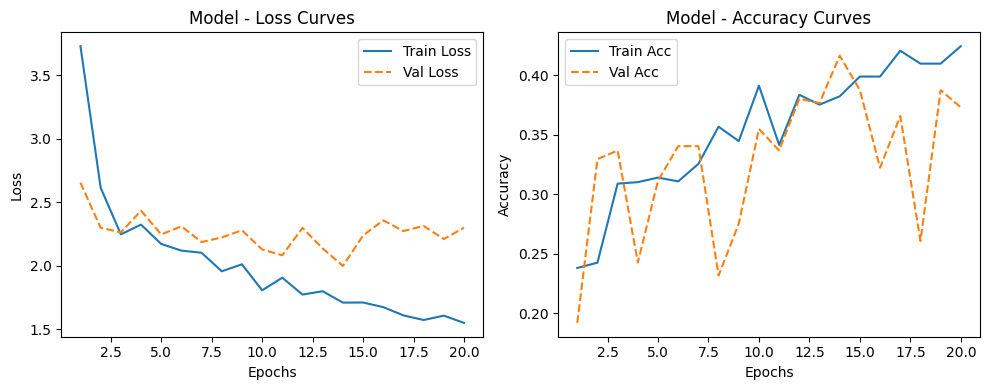


[TRAINING] Model=GIN, ArchID=init2
 Config: {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.3979, ValLoss=2.5415, TrainAcc=0.1980, ValAcc=0.1993
Epoch 02: TrainLoss=2.4285, ValLoss=2.4350, TrainAcc=0.2580, ValAcc=0.2681
Epoch 03: TrainLoss=2.3137, ValLoss=2.0915, TrainAcc=0.2593, ValAcc=0.3080
Epoch 04: TrainLoss=2.1478, ValLoss=2.2289, TrainAcc=0.2886, ValAcc=0.2174
Epoch 05: TrainLoss=2.1735, ValLoss=2.1007, TrainAcc=0.2886, ValAcc=0.3333
Epoch 06: TrainLoss=2.0772, ValLoss=2.0142, TrainAcc=0.3033, ValAcc=0.3913
Epoch 07: TrainLoss=2.0188, ValLoss=2.1026, TrainAcc=0.3212, ValAcc=0.3478
Epoch 08: TrainLoss=2.0781, ValLoss=2.0315, TrainAcc=0.3340, ValAcc=0.3333
Epoch 09: TrainLoss=2.0408, ValLoss=2.0745, TrainAcc=0.3199, ValAcc=0.3225
Epoch 10: TrainLoss=2.0028, ValLoss=2.1199, TrainAcc=0.3442, ValAcc=0.3152
Epoch 11: TrainLoss=1.9497, ValLoss=2.5305, TrainAcc=0.3352, ValAcc=0.3225
Epoch 12: TrainLoss=1.9360, ValLoss=1.99

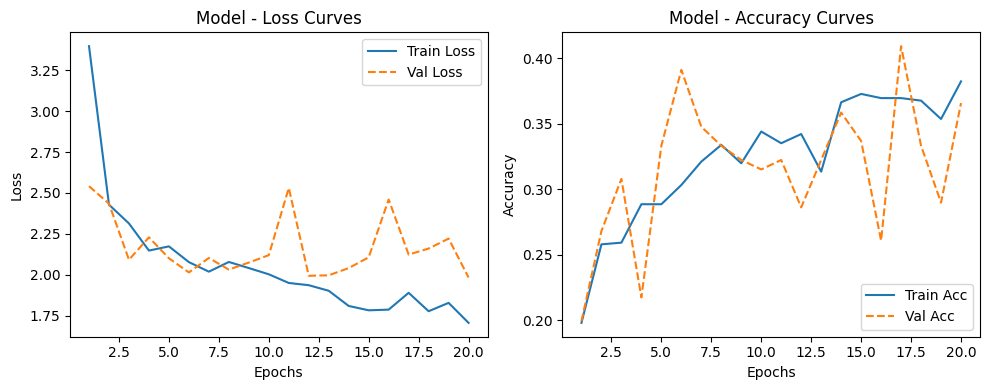


[TRAINING] Model=GIN, ArchID=init3
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3315210022502461, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.9453, ValLoss=2.1759, TrainAcc=0.2043, ValAcc=0.3587
Epoch 02: TrainLoss=2.6404, ValLoss=2.1330, TrainAcc=0.2395, ValAcc=0.2935
Epoch 03: TrainLoss=2.3303, ValLoss=2.0440, TrainAcc=0.2727, ValAcc=0.3261
Epoch 04: TrainLoss=2.1782, ValLoss=2.0581, TrainAcc=0.3033, ValAcc=0.3587
Epoch 05: TrainLoss=2.1924, ValLoss=2.0325, TrainAcc=0.3001, ValAcc=0.3768
Epoch 06: TrainLoss=2.0493, ValLoss=2.0889, TrainAcc=0.3218, ValAcc=0.3587
Epoch 07: TrainLoss=2.0511, ValLoss=2.0497, TrainAcc=0.3365, ValAcc=0.3551
Epoch 08: TrainLoss=1.9940, ValLoss=1.9327, TrainAcc=0.3423, ValAcc=0.3949
Epoch 09: TrainLoss=1.8556, ValLoss=1.9448, TrainAcc=0.3723, ValAcc=0.4239
Epoch 10: TrainLoss=1.9149, ValLoss=2.1000, TrainAcc=0.3748, ValAcc=0.2971
Epoch 11: TrainLoss=1.9412, ValLoss=1.9011, TrainAcc=0.3538, ValAcc=0.3478
Epoch 12: TrainLoss=1.7816, ValLoss=2.036

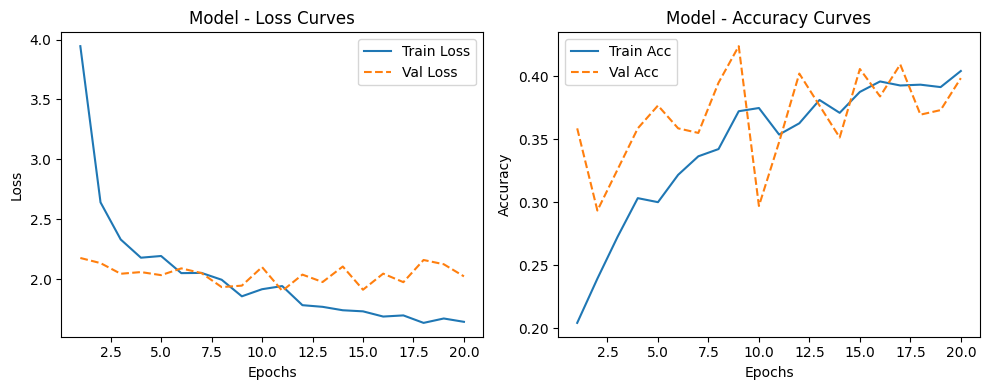


[TRAINING] Model=GIN, ArchID=iter1
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.1661, ValLoss=2.4263, TrainAcc=0.2344, ValAcc=0.2319
Epoch 02: TrainLoss=2.4515, ValLoss=2.1908, TrainAcc=0.2682, ValAcc=0.3551
Epoch 03: TrainLoss=2.3251, ValLoss=2.4503, TrainAcc=0.2874, ValAcc=0.2645
Epoch 04: TrainLoss=2.2147, ValLoss=2.2039, TrainAcc=0.2937, ValAcc=0.3116
Epoch 05: TrainLoss=2.2047, ValLoss=2.0297, TrainAcc=0.3116, ValAcc=0.3551
Epoch 06: TrainLoss=2.0935, ValLoss=2.2979, TrainAcc=0.3333, ValAcc=0.2717
Epoch 07: TrainLoss=2.1262, ValLoss=2.2982, TrainAcc=0.3161, ValAcc=0.3188
Epoch 08: TrainLoss=2.1223, ValLoss=2.2821, TrainAcc=0.3429, ValAcc=0.2536
Epoch 09: TrainLoss=2.0070, ValLoss=2.0453, TrainAcc=0.3423, ValAcc=0.4239
Epoch 10: TrainLoss=2.1682, ValLoss=2.0824, TrainAcc=0.3225, ValAcc=0.2862
Epoch 11: TrainLoss=2.1168, ValLoss=2.2395, TrainAcc=0.3365, ValAcc=0.3152
Epoch 12: TrainLoss=1.9199, ValLoss=2.1

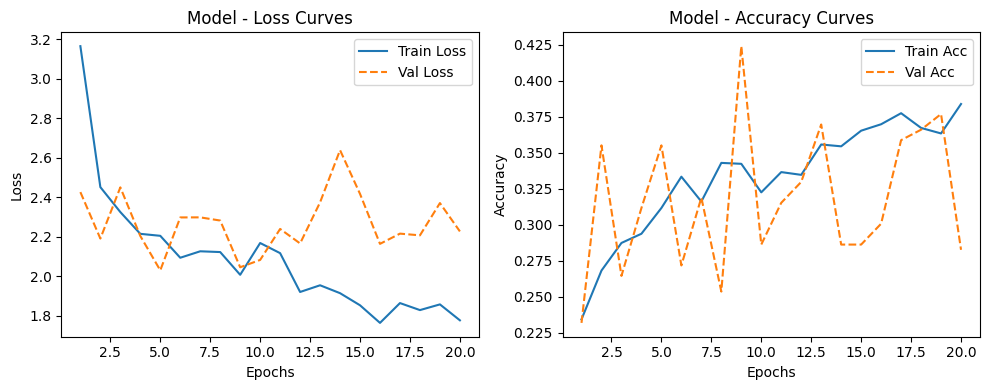

[GIN] Iter 1/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'sum'} -> ValAcc=0.4239

[TRAINING] Model=GIN, ArchID=iter2
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.2048, ValLoss=2.6621, TrainAcc=0.2292, ValAcc=0.1594
Epoch 02: TrainLoss=2.4815, ValLoss=2.2376, TrainAcc=0.2580, ValAcc=0.3152
Epoch 03: TrainLoss=2.3897, ValLoss=2.1815, TrainAcc=0.3008, ValAcc=0.2790
Epoch 04: TrainLoss=2.2774, ValLoss=2.1705, TrainAcc=0.2874, ValAcc=0.3768
Epoch 05: TrainLoss=2.2112, ValLoss=2.2963, TrainAcc=0.3416, ValAcc=0.2355
Epoch 06: TrainLoss=2.2582, ValLoss=2.3051, TrainAcc=0.3046, ValAcc=0.3478
Epoch 07: TrainLoss=2.0744, ValLoss=2.1395, TrainAcc=0.3352, ValAcc=0.3261
Epoch 08: TrainLoss=2.1780, ValLoss=2.0997, TrainAcc=0.3410, ValAcc=0.3225
Epoch 09: TrainLoss=2.1307, ValLoss=2.1255, TrainAcc=0.3340, ValAcc=0.3370
Epoch 10: TrainLoss=2.1843, ValLoss=2.3385, TrainAcc=0.

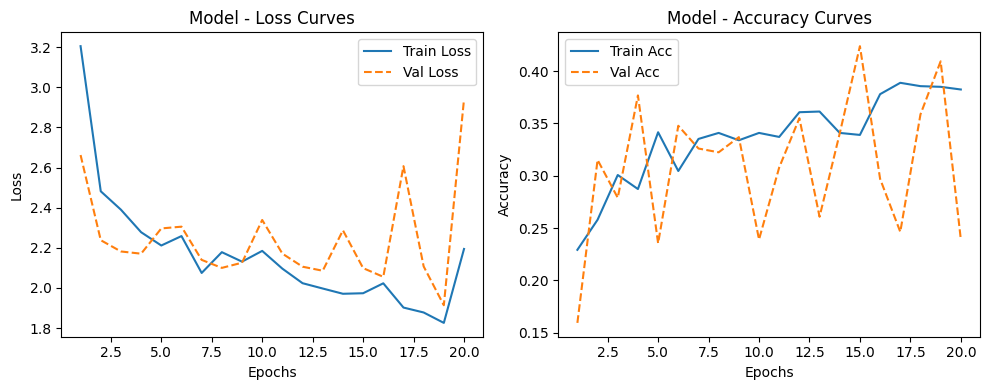

[GIN] Iter 2/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'sum'} -> ValAcc=0.4239

[TRAINING] Model=GIN, ArchID=iter3
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.4407, ValLoss=2.2169, TrainAcc=0.2695, ValAcc=0.3841
Epoch 02: TrainLoss=2.2059, ValLoss=2.1466, TrainAcc=0.3525, ValAcc=0.3080
Epoch 03: TrainLoss=2.0785, ValLoss=2.0062, TrainAcc=0.3876, ValAcc=0.4022
Epoch 04: TrainLoss=2.0027, ValLoss=2.0230, TrainAcc=0.4061, ValAcc=0.2899
Epoch 05: TrainLoss=2.0282, ValLoss=1.9007, TrainAcc=0.3768, ValAcc=0.4275
Epoch 06: TrainLoss=1.9780, ValLoss=2.1277, TrainAcc=0.4132, ValAcc=0.3370
Epoch 07: TrainLoss=1.8845, ValLoss=2.0831, TrainAcc=0.4272, ValAcc=0.3261
Epoch 08: TrainLoss=1.9023, ValLoss=2.1997, TrainAcc=0.3908, ValAcc=0.3478
Epoch 09: TrainLoss=1.8935, ValLoss=1.9745, TrainAcc=0.4125, ValAcc=0.3913
Epoch 10: TrainLoss=1.8242, ValLoss=1.7957, TrainAcc=0

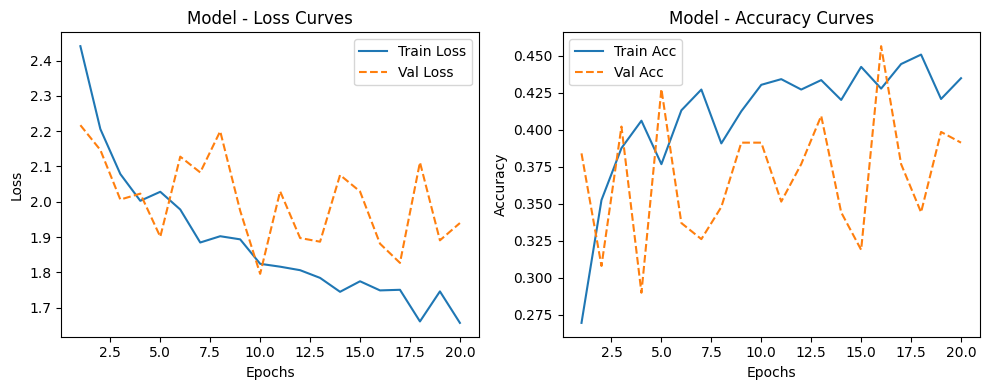

[GIN] Iter 3/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'} -> ValAcc=0.4565

[TRAINING] Model=GIN, ArchID=iter4
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.038401524157210765, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.1587, ValLoss=2.5973, TrainAcc=0.2031, ValAcc=0.1812
Epoch 02: TrainLoss=2.2943, ValLoss=2.5670, TrainAcc=0.2778, ValAcc=0.1812
Epoch 03: TrainLoss=2.2604, ValLoss=2.2082, TrainAcc=0.2963, ValAcc=0.3514
Epoch 04: TrainLoss=2.2377, ValLoss=2.1689, TrainAcc=0.2982, ValAcc=0.3551
Epoch 05: TrainLoss=2.1278, ValLoss=2.1706, TrainAcc=0.3110, ValAcc=0.3152
Epoch 06: TrainLoss=2.0310, ValLoss=2.3354, TrainAcc=0.3416, ValAcc=0.2500
Epoch 07: TrainLoss=2.0412, ValLoss=2.2273, TrainAcc=0.3110, ValAcc=0.3225
Epoch 08: TrainLoss=2.1601, ValLoss=2.0984, TrainAcc=0.3276, ValAcc=0.3478
Epoch 09: TrainLoss=2.0691, ValLoss=2.3884, TrainAcc=0.3455, ValAcc=0.3986
Epoch 10: TrainLoss=2.1565, ValLoss=2.4064, TrainAcc=

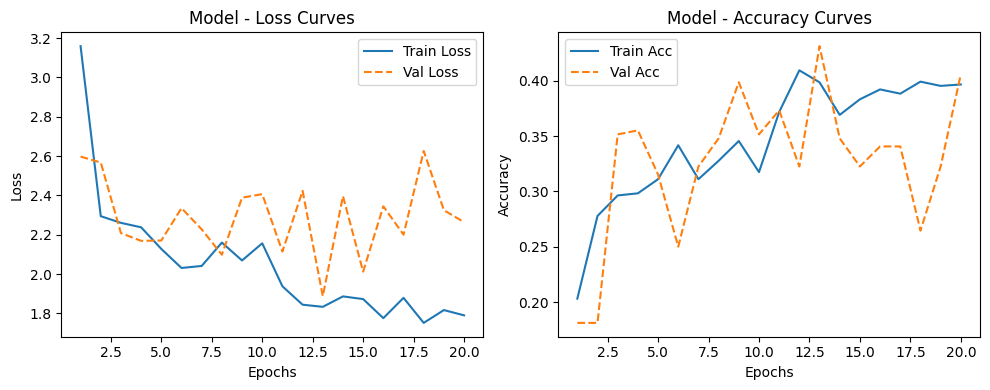

[GIN] Iter 4/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.038401524157210765, 'aggregation': 'sum'} -> ValAcc=0.4312

[TRAINING] Model=GIN, ArchID=iter5
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.06999368836088143, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.3873, ValLoss=2.4738, TrainAcc=0.2114, ValAcc=0.1812
Epoch 02: TrainLoss=2.5605, ValLoss=2.4282, TrainAcc=0.2458, ValAcc=0.2645
Epoch 03: TrainLoss=2.4248, ValLoss=2.1980, TrainAcc=0.2905, ValAcc=0.2971
Epoch 04: TrainLoss=2.2225, ValLoss=2.2466, TrainAcc=0.2976, ValAcc=0.2355
Epoch 05: TrainLoss=2.1306, ValLoss=2.1616, TrainAcc=0.3148, ValAcc=0.3877
Epoch 06: TrainLoss=2.1845, ValLoss=2.1056, TrainAcc=0.3180, ValAcc=0.2899
Epoch 07: TrainLoss=2.1003, ValLoss=2.0261, TrainAcc=0.3493, ValAcc=0.3442
Epoch 08: TrainLoss=2.1042, ValLoss=2.0923, TrainAcc=0.3321, ValAcc=0.3478
Epoch 09: TrainLoss=2.0775, ValLoss=2.1353, TrainAcc=0.3410, ValAcc=0.2754
Epoch 10: TrainLoss=1.9841, ValLoss=1.8880, TrainAcc=0

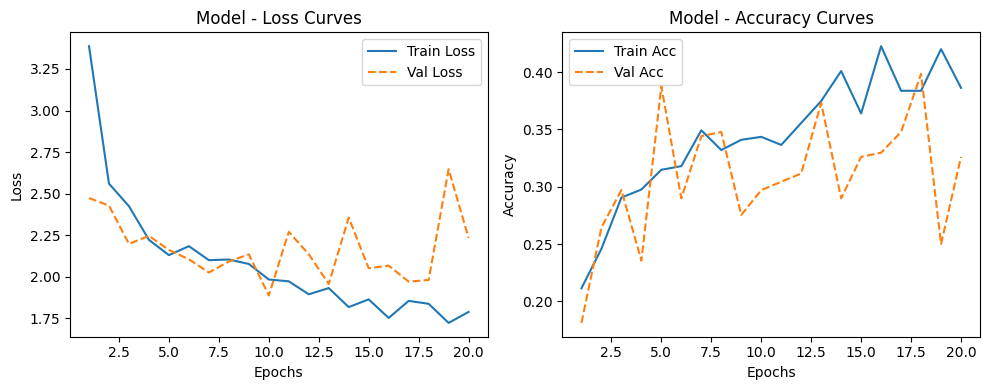

[GIN] Iter 5/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.06999368836088143, 'aggregation': 'sum'} -> ValAcc=0.3986

[TRAINING] Model=GIN, ArchID=iter6
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.09824348347810558, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.4571, ValLoss=2.3119, TrainAcc=0.2874, ValAcc=0.2681
Epoch 02: TrainLoss=2.2635, ValLoss=2.1028, TrainAcc=0.3308, ValAcc=0.3370
Epoch 03: TrainLoss=2.1178, ValLoss=2.1262, TrainAcc=0.3544, ValAcc=0.3841
Epoch 04: TrainLoss=2.0342, ValLoss=2.0670, TrainAcc=0.3902, ValAcc=0.4312
Epoch 05: TrainLoss=1.9912, ValLoss=2.0741, TrainAcc=0.3908, ValAcc=0.3659
Epoch 06: TrainLoss=2.0027, ValLoss=2.0512, TrainAcc=0.3768, ValAcc=0.4203
Epoch 07: TrainLoss=1.9544, ValLoss=1.9778, TrainAcc=0.4055, ValAcc=0.3659
Epoch 08: TrainLoss=1.8683, ValLoss=1.9889, TrainAcc=0.4055, ValAcc=0.3406
Epoch 09: TrainLoss=1.9619, ValLoss=1.9941, TrainAcc=0.3614, ValAcc=0.3261
Epoch 10: TrainLoss=1.9108, ValLoss=2.0333, TrainAcc=0

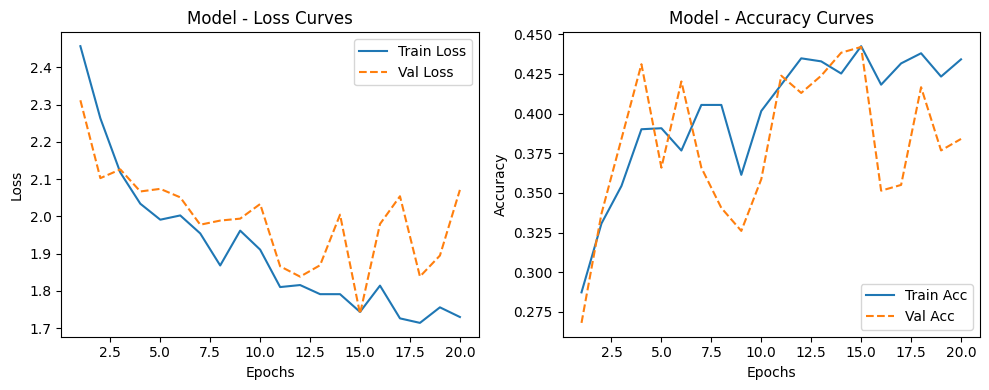

[GIN] Iter 6/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.09824348347810558, 'aggregation': 'mean'} -> ValAcc=0.4420

=== Best GIN Architecture ===
{'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'} Validation Accuracy: 0.4565

===== BANANAS SEARCH for GAT =====

[TRAINING] Model=GAT, ArchID=init1
 Config: {'hidden_dim': 32, 'num_layers': 3, 'dropout': 0.45693814516089815, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=3.2733, ValLoss=2.5469, TrainAcc=0.1041, ValAcc=0.1957
Epoch 02: TrainLoss=2.8518, ValLoss=2.5500, TrainAcc=0.1156, ValAcc=0.1848
Epoch 03: TrainLoss=2.9529, ValLoss=2.5486, TrainAcc=0.1098, ValAcc=0.1377
Epoch 04: TrainLoss=2.6719, ValLoss=2.5437, TrainAcc=0.1296, ValAcc=0.1957
Epoch 05: TrainLoss=2.6699, ValLoss=2.5423, TrainAcc=0.1513, ValAcc=0.1739
Epoch 06: TrainLoss=2.6821, ValLoss=2.5409, TrainAcc=0.1239, ValAcc=0.1920
Epoch 07: TrainLoss=2.6151, ValLoss=2.5347, TrainAcc=0.1379, ValAcc=0.2065
E

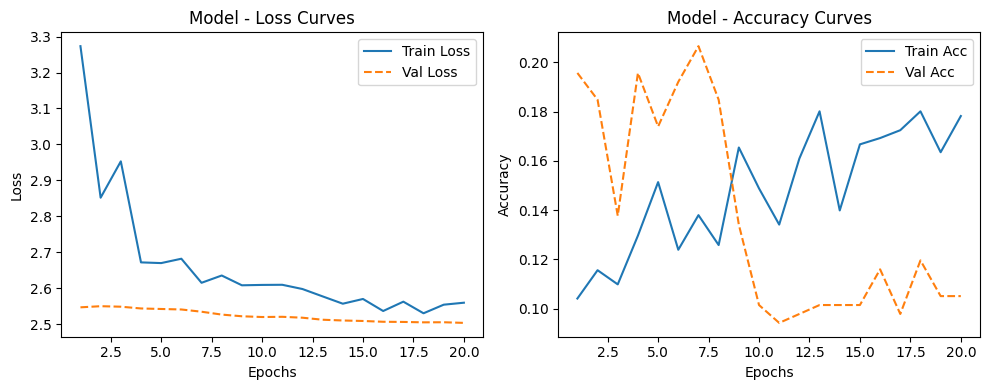


[TRAINING] Model=GAT, ArchID=init2
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.1776419871184613, 'num_heads': 2, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.5214, ValLoss=2.4221, TrainAcc=0.2152, ValAcc=0.3080
Epoch 02: TrainLoss=2.4486, ValLoss=2.3214, TrainAcc=0.2874, ValAcc=0.3913
Epoch 03: TrainLoss=2.3591, ValLoss=2.2311, TrainAcc=0.3148, ValAcc=0.3659
Epoch 04: TrainLoss=2.3409, ValLoss=2.2166, TrainAcc=0.3238, ValAcc=0.3696
Epoch 05: TrainLoss=2.2938, ValLoss=2.1635, TrainAcc=0.3333, ValAcc=0.3551
Epoch 06: TrainLoss=2.2135, ValLoss=2.1249, TrainAcc=0.3365, ValAcc=0.3877
Epoch 07: TrainLoss=2.1853, ValLoss=2.0892, TrainAcc=0.3301, ValAcc=0.3623
Epoch 08: TrainLoss=2.1424, ValLoss=2.0935, TrainAcc=0.3372, ValAcc=0.3587
Epoch 09: TrainLoss=2.1764, ValLoss=2.0919, TrainAcc=0.3282, ValAcc=0.3732
Epoch 10: TrainLoss=2.1584, ValLoss=2.1215, TrainAcc=0.3269, ValAcc=0.2862
Epoch 11: TrainLoss=2.0840, ValLoss=2.0904, TrainAcc=0.3455, ValAcc=0.3080
Epoch 12: TrainLoss=2.03

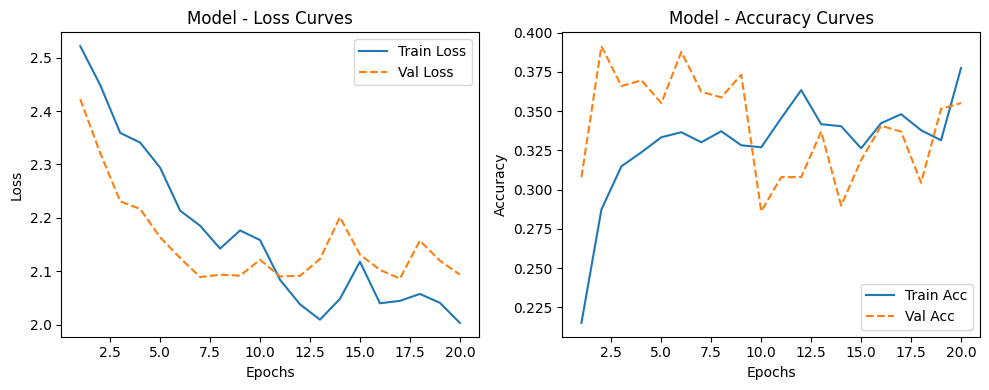


[TRAINING] Model=GAT, ArchID=init3
 Config: {'hidden_dim': 32, 'num_layers': 2, 'dropout': 0.3497671288077619, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.6133, ValLoss=2.5115, TrainAcc=0.0881, ValAcc=0.1377
Epoch 02: TrainLoss=2.5709, ValLoss=2.4934, TrainAcc=0.1507, ValAcc=0.1848
Epoch 03: TrainLoss=2.5448, ValLoss=2.4733, TrainAcc=0.1909, ValAcc=0.2428
Epoch 04: TrainLoss=2.5047, ValLoss=2.4506, TrainAcc=0.2088, ValAcc=0.2971
Epoch 05: TrainLoss=2.4990, ValLoss=2.4323, TrainAcc=0.2190, ValAcc=0.3043
Epoch 06: TrainLoss=2.4650, ValLoss=2.3986, TrainAcc=0.2497, ValAcc=0.3152
Epoch 07: TrainLoss=2.4636, ValLoss=2.3782, TrainAcc=0.2580, ValAcc=0.3442
Epoch 08: TrainLoss=2.4299, ValLoss=2.3523, TrainAcc=0.2593, ValAcc=0.3370
Epoch 09: TrainLoss=2.4251, ValLoss=2.3376, TrainAcc=0.2395, ValAcc=0.3188
Epoch 10: TrainLoss=2.4447, ValLoss=2.3097, TrainAcc=0.2701, ValAcc=0.3623
Epoch 11: TrainLoss=2.3845, ValLoss=2.2892, TrainAcc=0.2861, ValAcc=0.3261
Epoch 12: TrainLoss=2.37

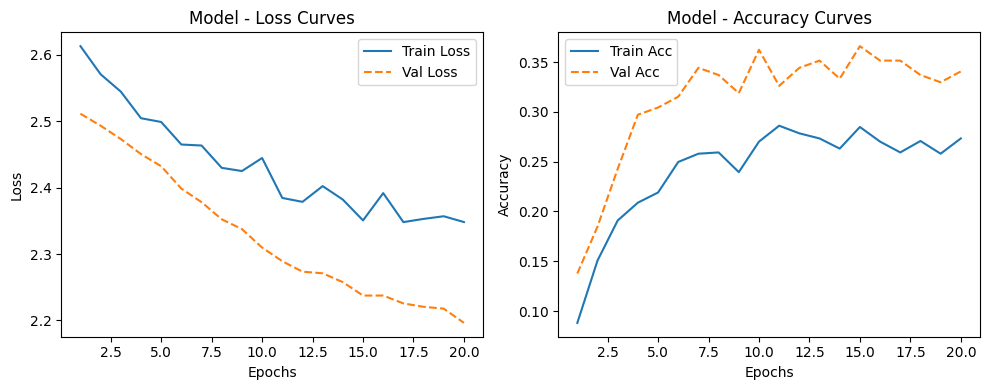


[TRAINING] Model=GAT, ArchID=iter1
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.1776419871184613, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.5324, ValLoss=2.4022, TrainAcc=0.1820, ValAcc=0.3080
Epoch 02: TrainLoss=2.3956, ValLoss=2.2475, TrainAcc=0.2848, ValAcc=0.3949
Epoch 03: TrainLoss=2.3221, ValLoss=2.1619, TrainAcc=0.3263, ValAcc=0.3768
Epoch 04: TrainLoss=2.2736, ValLoss=2.1146, TrainAcc=0.3423, ValAcc=0.3804
Epoch 05: TrainLoss=2.2419, ValLoss=2.0951, TrainAcc=0.3455, ValAcc=0.3406
Epoch 06: TrainLoss=2.1978, ValLoss=2.0556, TrainAcc=0.3263, ValAcc=0.3478
Epoch 07: TrainLoss=2.1491, ValLoss=2.0351, TrainAcc=0.3346, ValAcc=0.3732
Epoch 08: TrainLoss=2.1304, ValLoss=2.0211, TrainAcc=0.3493, ValAcc=0.3768
Epoch 09: TrainLoss=2.1422, ValLoss=2.0330, TrainAcc=0.3499, ValAcc=0.3333
Epoch 10: TrainLoss=2.1118, ValLoss=2.0321, TrainAcc=0.3570, ValAcc=0.3623
Epoch 11: TrainLoss=2.0841, ValLoss=2.0436, TrainAcc=0.3480, ValAcc=0.3333
Epoch 12: TrainLoss=2.07

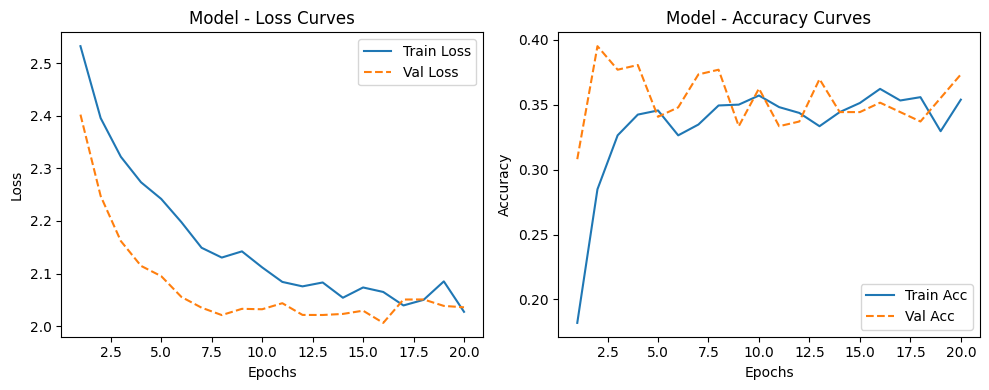

[GAT] Iter 1/6 | New Arch {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.1776419871184613, 'num_heads': 8, 'aggregation': 'mean'} -> ValAcc=0.3949

[TRAINING] Model=GAT, ArchID=iter2
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3412996398906527, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.5647, ValLoss=2.4871, TrainAcc=0.1948, ValAcc=0.2609
Epoch 02: TrainLoss=2.4868, ValLoss=2.4170, TrainAcc=0.2388, ValAcc=0.3043
Epoch 03: TrainLoss=2.4634, ValLoss=2.3690, TrainAcc=0.2771, ValAcc=0.3080
Epoch 04: TrainLoss=2.4405, ValLoss=2.3270, TrainAcc=0.2465, ValAcc=0.3406
Epoch 05: TrainLoss=2.4480, ValLoss=2.3218, TrainAcc=0.2720, ValAcc=0.3297
Epoch 06: TrainLoss=2.4021, ValLoss=2.2800, TrainAcc=0.2580, ValAcc=0.3514
Epoch 07: TrainLoss=2.3807, ValLoss=2.2504, TrainAcc=0.2944, ValAcc=0.3514
Epoch 08: TrainLoss=2.3656, ValLoss=2.2202, TrainAcc=0.2835, ValAcc=0.3841
Epoch 09: TrainLoss=2.3114, ValLoss=2.2014, TrainAcc=0.2867, ValAcc=0.3225
Epoch 10: TrainLoss=2.346

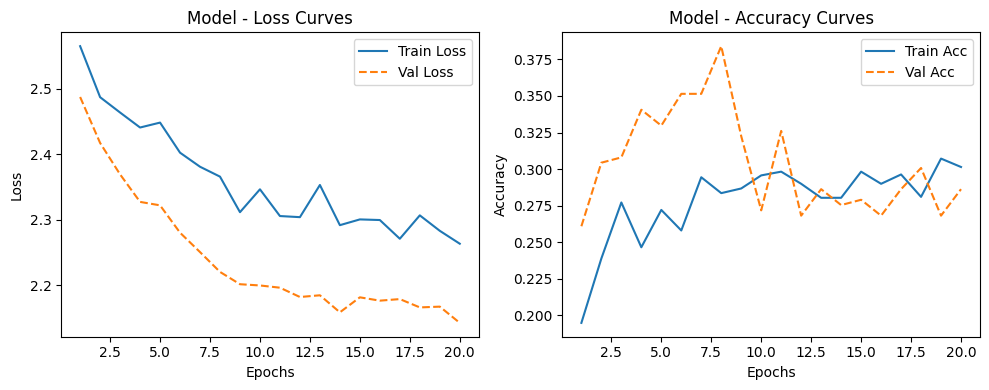

[GAT] Iter 2/6 | New Arch {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3412996398906527, 'num_heads': 8, 'aggregation': 'mean'} -> ValAcc=0.3841

[TRAINING] Model=GAT, ArchID=iter3
 Config: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.45693814516089815, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=3.2528, ValLoss=2.5741, TrainAcc=0.1226, ValAcc=0.0181
Epoch 02: TrainLoss=2.8954, ValLoss=2.5703, TrainAcc=0.1105, ValAcc=0.0109
Epoch 03: TrainLoss=2.8527, ValLoss=2.5592, TrainAcc=0.1271, ValAcc=0.0362
Epoch 04: TrainLoss=2.6785, ValLoss=2.5523, TrainAcc=0.1290, ValAcc=0.0362
Epoch 05: TrainLoss=2.6406, ValLoss=2.5464, TrainAcc=0.1450, ValAcc=0.0290
Epoch 06: TrainLoss=2.6267, ValLoss=2.5438, TrainAcc=0.1309, ValAcc=0.0326
Epoch 07: TrainLoss=2.5936, ValLoss=2.5407, TrainAcc=0.1347, ValAcc=0.0471
Epoch 08: TrainLoss=2.6110, ValLoss=2.5348, TrainAcc=0.1616, ValAcc=0.0543
Epoch 09: TrainLoss=2.5993, ValLoss=2.5318, TrainAcc=0.1507, ValAcc=0.0399
Epoch 10: TrainLoss=2.58

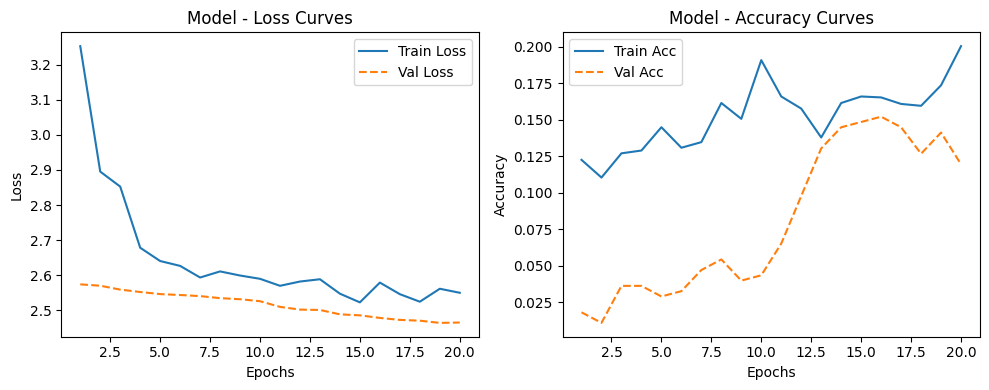

[GAT] Iter 3/6 | New Arch {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.45693814516089815, 'num_heads': 8, 'aggregation': 'mean'} -> ValAcc=0.1522

[TRAINING] Model=GAT, ArchID=iter4
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3412996398906527, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.5617, ValLoss=2.5129, TrainAcc=0.1705, ValAcc=0.3188
Epoch 02: TrainLoss=2.5055, ValLoss=2.4422, TrainAcc=0.2510, ValAcc=0.3478
Epoch 03: TrainLoss=2.4910, ValLoss=2.3915, TrainAcc=0.2631, ValAcc=0.3188
Epoch 04: TrainLoss=2.4226, ValLoss=2.3360, TrainAcc=0.2708, ValAcc=0.3478
Epoch 05: TrainLoss=2.4232, ValLoss=2.3029, TrainAcc=0.2656, ValAcc=0.3370
Epoch 06: TrainLoss=2.3699, ValLoss=2.2582, TrainAcc=0.2727, ValAcc=0.3442
Epoch 07: TrainLoss=2.3471, ValLoss=2.2394, TrainAcc=0.2957, ValAcc=0.3333
Epoch 08: TrainLoss=2.3372, ValLoss=2.2137, TrainAcc=0.2784, ValAcc=0.3297
Epoch 09: TrainLoss=2.3480, ValLoss=2.2131, TrainAcc=0.2752, ValAcc=0.2935
Epoch 10: TrainLoss=2.30

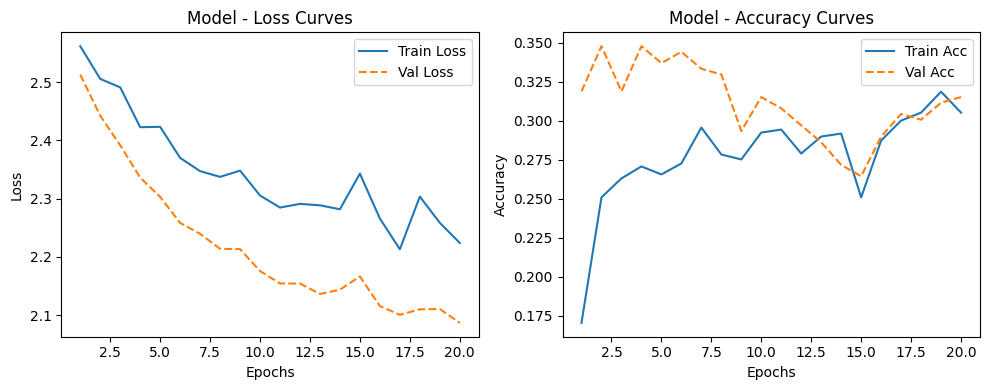

[GAT] Iter 4/6 | New Arch {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3412996398906527, 'num_heads': 8, 'aggregation': 'mean'} -> ValAcc=0.3478

[TRAINING] Model=GAT, ArchID=iter5
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.10806790615546036, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.5045, ValLoss=2.3611, TrainAcc=0.1903, ValAcc=0.3841
Epoch 02: TrainLoss=2.3597, ValLoss=2.1944, TrainAcc=0.3429, ValAcc=0.4022
Epoch 03: TrainLoss=2.2667, ValLoss=2.1128, TrainAcc=0.3538, ValAcc=0.3877
Epoch 04: TrainLoss=2.1995, ValLoss=2.0719, TrainAcc=0.3640, ValAcc=0.3804
Epoch 05: TrainLoss=2.1256, ValLoss=2.0401, TrainAcc=0.3659, ValAcc=0.3659
Epoch 06: TrainLoss=2.0643, ValLoss=2.0116, TrainAcc=0.3627, ValAcc=0.3913
Epoch 07: TrainLoss=2.0437, ValLoss=2.0562, TrainAcc=0.3755, ValAcc=0.3696
Epoch 08: TrainLoss=2.0515, ValLoss=2.0477, TrainAcc=0.3627, ValAcc=0.3478
Epoch 09: TrainLoss=2.0155, ValLoss=2.0163, TrainAcc=0.3793, ValAcc=0.3623
Epoch 10: TrainLoss=2.00

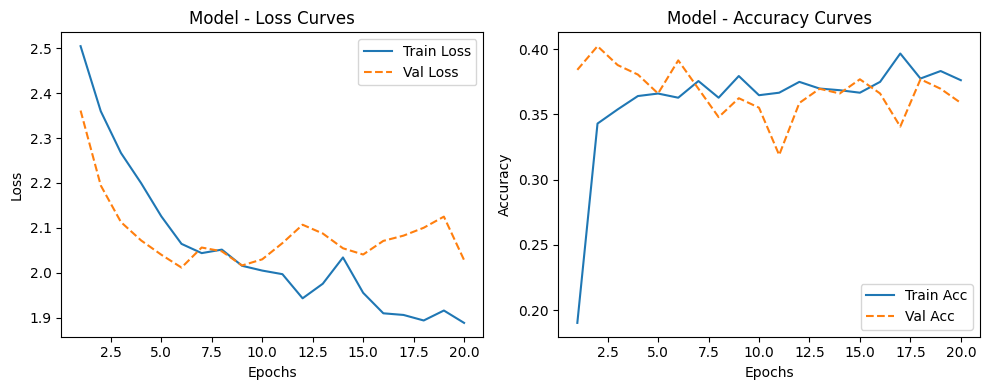

[GAT] Iter 5/6 | New Arch {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.10806790615546036, 'num_heads': 8, 'aggregation': 'mean'} -> ValAcc=0.4022

[TRAINING] Model=GAT, ArchID=iter6
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3412996398906527, 'num_heads': 8, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.5443, ValLoss=2.4648, TrainAcc=0.1762, ValAcc=0.1920
Epoch 02: TrainLoss=2.4857, ValLoss=2.3931, TrainAcc=0.2401, ValAcc=0.2826
Epoch 03: TrainLoss=2.4408, ValLoss=2.3281, TrainAcc=0.2599, ValAcc=0.3696
Epoch 04: TrainLoss=2.4150, ValLoss=2.2813, TrainAcc=0.2612, ValAcc=0.3551
Epoch 05: TrainLoss=2.3827, ValLoss=2.2489, TrainAcc=0.2822, ValAcc=0.3696
Epoch 06: TrainLoss=2.4076, ValLoss=2.2080, TrainAcc=0.2874, ValAcc=0.3478
Epoch 07: TrainLoss=2.3616, ValLoss=2.1982, TrainAcc=0.2905, ValAcc=0.3152
Epoch 08: TrainLoss=2.3521, ValLoss=2.1781, TrainAcc=0.2899, ValAcc=0.3188
Epoch 09: TrainLoss=2.3516, ValLoss=2.1474, TrainAcc=0.2848, ValAcc=0.3333
Epoch 10: TrainLoss=2.31

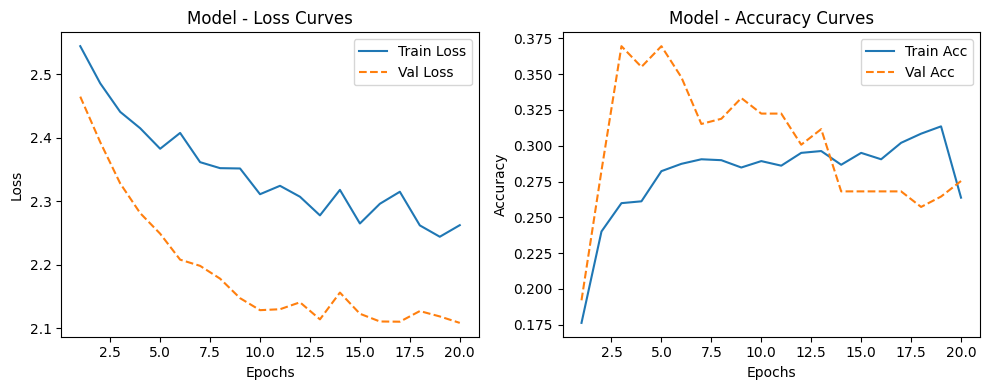

[GAT] Iter 6/6 | New Arch {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3412996398906527, 'num_heads': 8, 'aggregation': 'mean'} -> ValAcc=0.3696

=== Best GAT Architecture ===
{'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.10806790615546036, 'num_heads': 8, 'aggregation': 'mean'} Validation Accuracy: 0.4022

===== BANANAS SEARCH for DiffPool =====

[TRAINING] Model=DiffPool, ArchID=init1
 Config: {'hidden_dim': 128, 'assign_dim': 4, 'embed_dim': 64}
Epoch 01: TrainLoss=2.5518, ValLoss=2.4895, TrainAcc=0.1296, ValAcc=0.2935
Epoch 02: TrainLoss=2.5088, ValLoss=2.4614, TrainAcc=0.2586, ValAcc=0.2971
Epoch 03: TrainLoss=2.4227, ValLoss=2.2998, TrainAcc=0.2618, ValAcc=0.3043
Epoch 04: TrainLoss=2.3189, ValLoss=2.1984, TrainAcc=0.3206, ValAcc=0.3768
Epoch 05: TrainLoss=2.2177, ValLoss=2.1200, TrainAcc=0.3646, ValAcc=0.3877
Epoch 06: TrainLoss=2.1344, ValLoss=2.0395, TrainAcc=0.3621, ValAcc=0.4130
Epoch 07: TrainLoss=2.0793, ValLoss=2.0067, TrainAcc=0.3953, ValAcc=0.3986
Epoch 08: Train

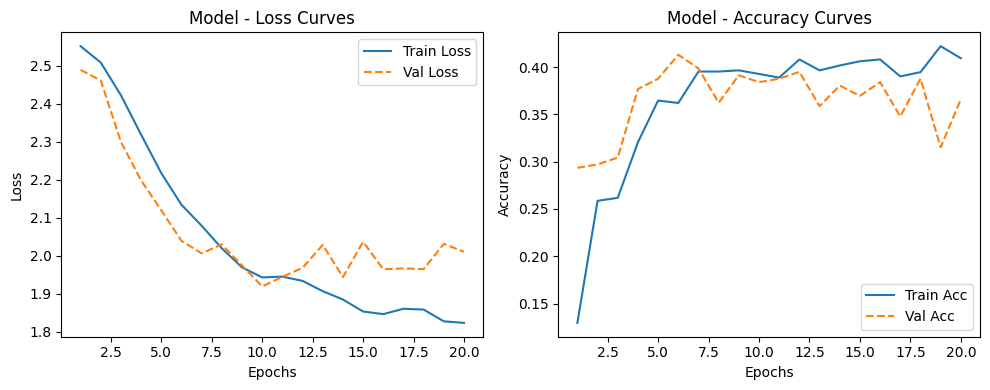


[TRAINING] Model=DiffPool, ArchID=init2
 Config: {'hidden_dim': 32, 'assign_dim': 4, 'embed_dim': 64}
Epoch 01: TrainLoss=2.5549, ValLoss=2.5215, TrainAcc=0.1724, ValAcc=0.2935
Epoch 02: TrainLoss=2.5329, ValLoss=2.4949, TrainAcc=0.1992, ValAcc=0.2971
Epoch 03: TrainLoss=2.5074, ValLoss=2.4658, TrainAcc=0.2784, ValAcc=0.2826
Epoch 04: TrainLoss=2.4715, ValLoss=2.4087, TrainAcc=0.3001, ValAcc=0.2790
Epoch 05: TrainLoss=2.4111, ValLoss=2.3230, TrainAcc=0.3199, ValAcc=0.3478
Epoch 06: TrainLoss=2.3172, ValLoss=2.2025, TrainAcc=0.3257, ValAcc=0.2790
Epoch 07: TrainLoss=2.2682, ValLoss=2.1591, TrainAcc=0.3084, ValAcc=0.3261
Epoch 08: TrainLoss=2.2000, ValLoss=2.0987, TrainAcc=0.3276, ValAcc=0.3732
Epoch 09: TrainLoss=2.1665, ValLoss=2.0643, TrainAcc=0.3665, ValAcc=0.3478
Epoch 10: TrainLoss=2.1114, ValLoss=2.0238, TrainAcc=0.3512, ValAcc=0.3877
Epoch 11: TrainLoss=2.0898, ValLoss=2.0182, TrainAcc=0.3576, ValAcc=0.3478
Epoch 12: TrainLoss=2.0523, ValLoss=1.9831, TrainAcc=0.3697, ValAcc=0.35

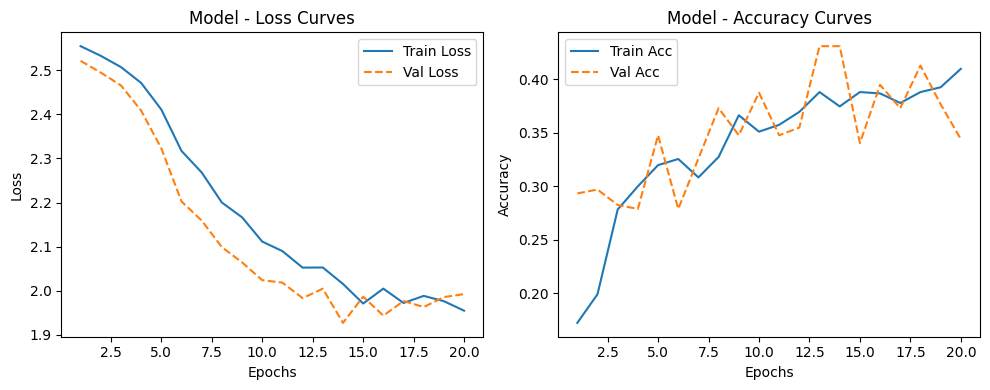


[TRAINING] Model=DiffPool, ArchID=init3
 Config: {'hidden_dim': 64, 'assign_dim': 8, 'embed_dim': 32}
Epoch 01: TrainLoss=2.5614, ValLoss=2.5294, TrainAcc=0.1724, ValAcc=0.2681
Epoch 02: TrainLoss=2.5217, ValLoss=2.4753, TrainAcc=0.1960, ValAcc=0.2645
Epoch 03: TrainLoss=2.4867, ValLoss=2.4255, TrainAcc=0.2427, ValAcc=0.2681
Epoch 04: TrainLoss=2.4335, ValLoss=2.3205, TrainAcc=0.2905, ValAcc=0.3333
Epoch 05: TrainLoss=2.3506, ValLoss=2.2352, TrainAcc=0.3014, ValAcc=0.3442
Epoch 06: TrainLoss=2.2560, ValLoss=2.1580, TrainAcc=0.3174, ValAcc=0.3986
Epoch 07: TrainLoss=2.2106, ValLoss=2.1202, TrainAcc=0.3263, ValAcc=0.3370
Epoch 08: TrainLoss=2.1824, ValLoss=2.0651, TrainAcc=0.3448, ValAcc=0.3768
Epoch 09: TrainLoss=2.1250, ValLoss=2.0375, TrainAcc=0.3301, ValAcc=0.3732
Epoch 10: TrainLoss=2.0989, ValLoss=1.9935, TrainAcc=0.3608, ValAcc=0.3696
Epoch 11: TrainLoss=2.0563, ValLoss=2.0213, TrainAcc=0.3793, ValAcc=0.3913
Epoch 12: TrainLoss=2.0152, ValLoss=1.9626, TrainAcc=0.3793, ValAcc=0.36

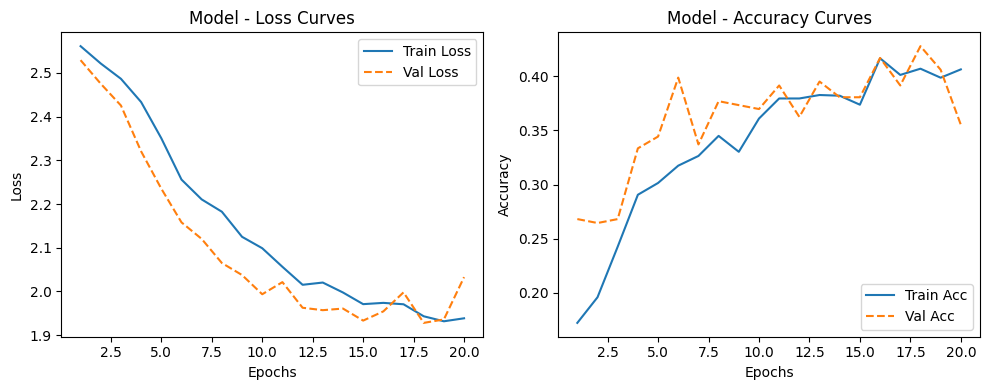


[TRAINING] Model=DiffPool, ArchID=iter1
 Config: {'hidden_dim': 128, 'assign_dim': 4, 'embed_dim': 16}
Epoch 01: TrainLoss=2.5802, ValLoss=2.5760, TrainAcc=0.0715, ValAcc=0.0688
Epoch 02: TrainLoss=2.5334, ValLoss=2.5159, TrainAcc=0.0920, ValAcc=0.1848
Epoch 03: TrainLoss=2.4763, ValLoss=2.4212, TrainAcc=0.3212, ValAcc=0.3551
Epoch 04: TrainLoss=2.4012, ValLoss=2.3273, TrainAcc=0.3180, ValAcc=0.3696
Epoch 05: TrainLoss=2.3303, ValLoss=2.2423, TrainAcc=0.3455, ValAcc=0.3732
Epoch 06: TrainLoss=2.2562, ValLoss=2.1838, TrainAcc=0.3736, ValAcc=0.3877
Epoch 07: TrainLoss=2.1906, ValLoss=2.1439, TrainAcc=0.3825, ValAcc=0.3913
Epoch 08: TrainLoss=2.1578, ValLoss=2.1033, TrainAcc=0.3972, ValAcc=0.4167
Epoch 09: TrainLoss=2.1235, ValLoss=2.1070, TrainAcc=0.3972, ValAcc=0.3804
Epoch 10: TrainLoss=2.0646, ValLoss=2.0780, TrainAcc=0.4195, ValAcc=0.3768
Epoch 11: TrainLoss=2.0408, ValLoss=2.0206, TrainAcc=0.4080, ValAcc=0.4058
Epoch 12: TrainLoss=2.0225, ValLoss=1.9937, TrainAcc=0.4170, ValAcc=0.4

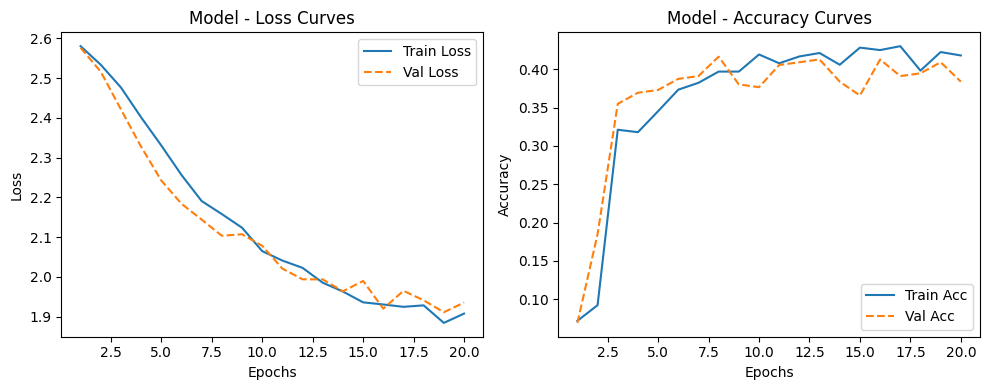

[DiffPool] Iter 1/6 | New Arch {'hidden_dim': 128, 'assign_dim': 4, 'embed_dim': 16} -> ValAcc=0.4167

[TRAINING] Model=DiffPool, ArchID=iter2
 Config: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64}
Epoch 01: TrainLoss=2.5531, ValLoss=2.5052, TrainAcc=0.2414, ValAcc=0.2754
Epoch 02: TrainLoss=2.4997, ValLoss=2.4250, TrainAcc=0.2739, ValAcc=0.3116
Epoch 03: TrainLoss=2.4237, ValLoss=2.2945, TrainAcc=0.2957, ValAcc=0.3514
Epoch 04: TrainLoss=2.2895, ValLoss=2.1750, TrainAcc=0.3665, ValAcc=0.3659
Epoch 05: TrainLoss=2.2188, ValLoss=2.1389, TrainAcc=0.3461, ValAcc=0.3696
Epoch 06: TrainLoss=2.1362, ValLoss=2.0456, TrainAcc=0.3806, ValAcc=0.3949
Epoch 07: TrainLoss=2.0604, ValLoss=1.9695, TrainAcc=0.3908, ValAcc=0.3804
Epoch 08: TrainLoss=2.0314, ValLoss=2.0058, TrainAcc=0.3953, ValAcc=0.3913
Epoch 09: TrainLoss=1.9757, ValLoss=1.9508, TrainAcc=0.3863, ValAcc=0.3804
Epoch 10: TrainLoss=1.9382, ValLoss=1.9558, TrainAcc=0.4093, ValAcc=0.3841
Epoch 11: TrainLoss=1.9216, ValLoss=2.0051,

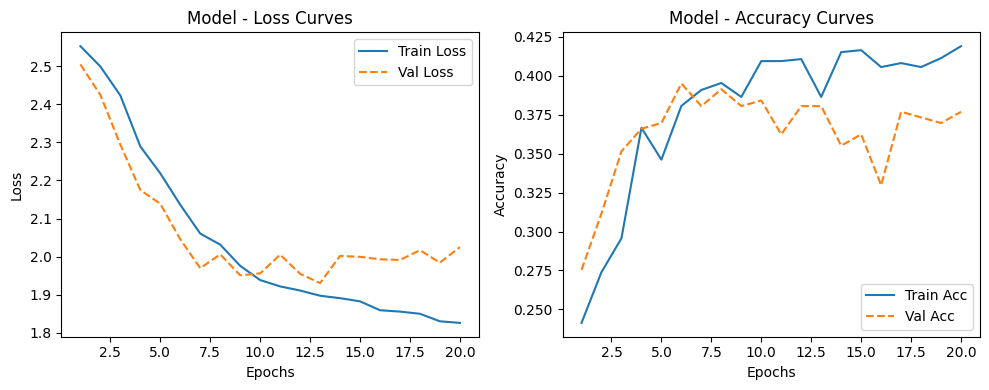

[DiffPool] Iter 2/6 | New Arch {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64} -> ValAcc=0.3949

[TRAINING] Model=DiffPool, ArchID=iter3
 Config: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64}
Epoch 01: TrainLoss=2.5604, ValLoss=2.5140, TrainAcc=0.1839, ValAcc=0.3551
Epoch 02: TrainLoss=2.5192, ValLoss=2.4740, TrainAcc=0.3084, ValAcc=0.3696
Epoch 03: TrainLoss=2.4585, ValLoss=2.3581, TrainAcc=0.3218, ValAcc=0.3478
Epoch 04: TrainLoss=2.3532, ValLoss=2.1954, TrainAcc=0.3257, ValAcc=0.3841
Epoch 05: TrainLoss=2.2257, ValLoss=2.1055, TrainAcc=0.3480, ValAcc=0.3370
Epoch 06: TrainLoss=2.1633, ValLoss=2.0771, TrainAcc=0.3602, ValAcc=0.3841
Epoch 07: TrainLoss=2.0805, ValLoss=2.0375, TrainAcc=0.3889, ValAcc=0.3442
Epoch 08: TrainLoss=2.0490, ValLoss=2.0061, TrainAcc=0.3672, ValAcc=0.4130
Epoch 09: TrainLoss=2.0065, ValLoss=2.0250, TrainAcc=0.3946, ValAcc=0.3696
Epoch 10: TrainLoss=1.9813, ValLoss=1.9880, TrainAcc=0.3953, ValAcc=0.3841
Epoch 11: TrainLoss=1.9465, ValLoss=1.9767

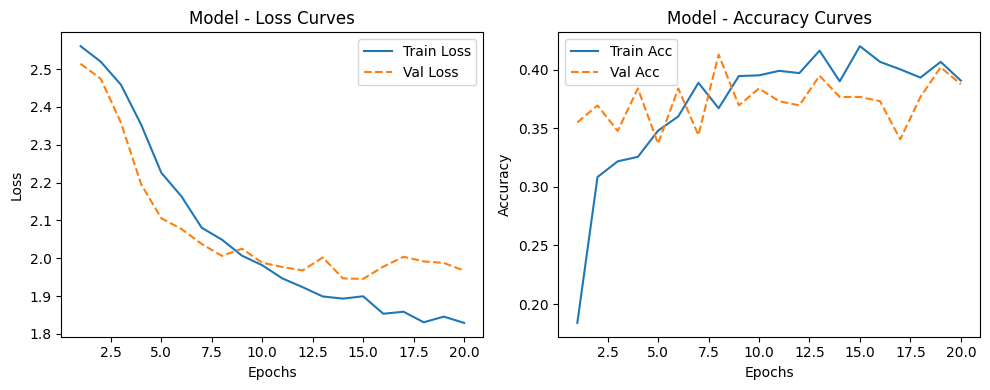

[DiffPool] Iter 3/6 | New Arch {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64} -> ValAcc=0.4130

[TRAINING] Model=DiffPool, ArchID=iter4
 Config: {'hidden_dim': 32, 'assign_dim': 16, 'embed_dim': 64}
Epoch 01: TrainLoss=2.5562, ValLoss=2.5011, TrainAcc=0.2465, ValAcc=0.2754
Epoch 02: TrainLoss=2.5279, ValLoss=2.4768, TrainAcc=0.2063, ValAcc=0.2862
Epoch 03: TrainLoss=2.5032, ValLoss=2.4477, TrainAcc=0.2803, ValAcc=0.2754
Epoch 04: TrainLoss=2.4584, ValLoss=2.3814, TrainAcc=0.3135, ValAcc=0.3406
Epoch 05: TrainLoss=2.4050, ValLoss=2.3137, TrainAcc=0.3295, ValAcc=0.3623
Epoch 06: TrainLoss=2.3461, ValLoss=2.2551, TrainAcc=0.3384, ValAcc=0.3913
Epoch 07: TrainLoss=2.2920, ValLoss=2.2165, TrainAcc=0.3570, ValAcc=0.3406
Epoch 08: TrainLoss=2.2176, ValLoss=2.1510, TrainAcc=0.3710, ValAcc=0.3587
Epoch 09: TrainLoss=2.1851, ValLoss=2.1032, TrainAcc=0.3755, ValAcc=0.3587
Epoch 10: TrainLoss=2.1336, ValLoss=2.0971, TrainAcc=0.3519, ValAcc=0.3913
Epoch 11: TrainLoss=2.1166, ValLoss=2.0973,

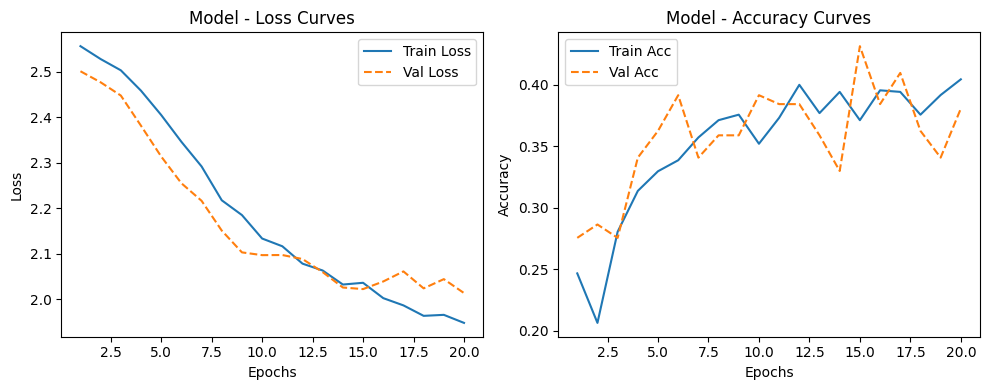

[DiffPool] Iter 4/6 | New Arch {'hidden_dim': 32, 'assign_dim': 16, 'embed_dim': 64} -> ValAcc=0.4312

[TRAINING] Model=DiffPool, ArchID=iter5
 Config: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 16}
Epoch 01: TrainLoss=2.5625, ValLoss=2.5278, TrainAcc=0.1833, ValAcc=0.2681
Epoch 02: TrainLoss=2.5251, ValLoss=2.4773, TrainAcc=0.2701, ValAcc=0.2826
Epoch 03: TrainLoss=2.4897, ValLoss=2.4383, TrainAcc=0.3052, ValAcc=0.2935
Epoch 04: TrainLoss=2.4364, ValLoss=2.3751, TrainAcc=0.3052, ValAcc=0.3116
Epoch 05: TrainLoss=2.3860, ValLoss=2.2925, TrainAcc=0.3340, ValAcc=0.3007
Epoch 06: TrainLoss=2.3134, ValLoss=2.2210, TrainAcc=0.3397, ValAcc=0.3116
Epoch 07: TrainLoss=2.2434, ValLoss=2.1453, TrainAcc=0.3404, ValAcc=0.3623
Epoch 08: TrainLoss=2.2007, ValLoss=2.0963, TrainAcc=0.3429, ValAcc=0.3732
Epoch 09: TrainLoss=2.1665, ValLoss=2.0658, TrainAcc=0.3640, ValAcc=0.3732
Epoch 10: TrainLoss=2.1361, ValLoss=2.0576, TrainAcc=0.3736, ValAcc=0.3696
Epoch 11: TrainLoss=2.1073, ValLoss=2.0004,

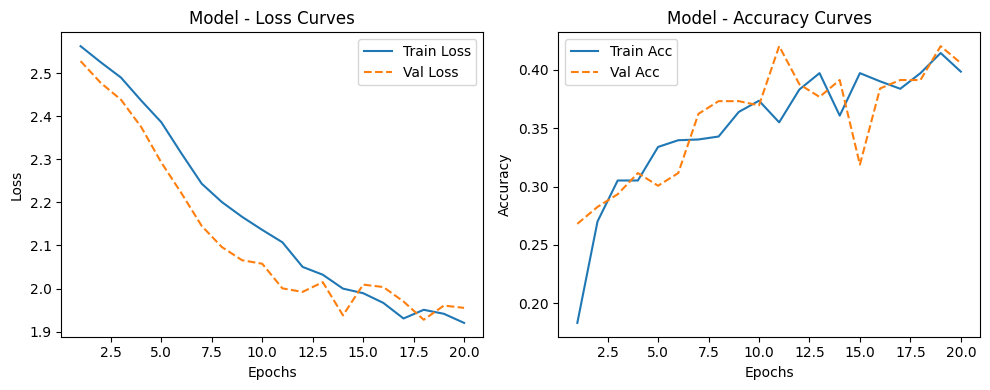

[DiffPool] Iter 5/6 | New Arch {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 16} -> ValAcc=0.4203

[TRAINING] Model=DiffPool, ArchID=iter6
 Config: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 32}
Epoch 01: TrainLoss=2.5506, ValLoss=2.5099, TrainAcc=0.1322, ValAcc=0.1304
Epoch 02: TrainLoss=2.5206, ValLoss=2.4767, TrainAcc=0.1845, ValAcc=0.2355
Epoch 03: TrainLoss=2.4783, ValLoss=2.3900, TrainAcc=0.2727, ValAcc=0.2717
Epoch 04: TrainLoss=2.4057, ValLoss=2.2842, TrainAcc=0.2867, ValAcc=0.2899
Epoch 05: TrainLoss=2.2884, ValLoss=2.1507, TrainAcc=0.3186, ValAcc=0.3913
Epoch 06: TrainLoss=2.2091, ValLoss=2.0856, TrainAcc=0.3487, ValAcc=0.3551
Epoch 07: TrainLoss=2.1095, ValLoss=2.0211, TrainAcc=0.3710, ValAcc=0.4022
Epoch 08: TrainLoss=2.0705, ValLoss=1.9883, TrainAcc=0.3870, ValAcc=0.3913
Epoch 09: TrainLoss=2.0318, ValLoss=2.0199, TrainAcc=0.3914, ValAcc=0.4130
Epoch 10: TrainLoss=1.9823, ValLoss=1.9486, TrainAcc=0.4087, ValAcc=0.3696
Epoch 11: TrainLoss=1.9809, ValLoss=1.9517

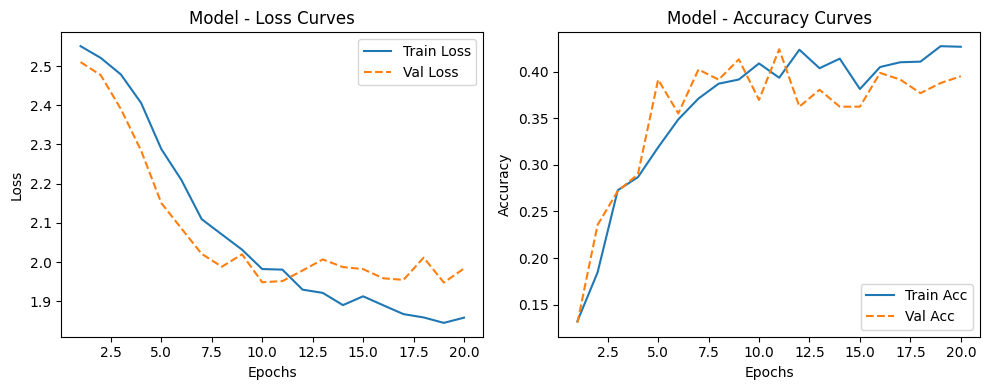

[DiffPool] Iter 6/6 | New Arch {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 32} -> ValAcc=0.4239

=== Best DiffPool Architecture ===
{'hidden_dim': 32, 'assign_dim': 4, 'embed_dim': 64} Validation Accuracy: 0.4312

--- Best Architectures Found ---
Best GIN Architecture: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'}
Best GAT Architecture: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.10806790615546036, 'num_heads': 8, 'aggregation': 'mean'}
Best DiffPool Architecture: {'hidden_dim': 32, 'assign_dim': 4, 'embed_dim': 64}
BANANAS architecture search completed for GIN, GAT, GCN, and DiffPool models.


In [ ]:
# Arch search spaces
arch_space_gin = {
    "hidden_dim": [32, 64, 128],
    "num_layers": [2, 3, 4, 5],
    "dropout": [0.0, 0.25, 0.5],
    "aggregation": ['sum', 'mean']
}
arch_space_gat = {
    "hidden_dim": [32, 64],
    "num_layers": [2, 3, 4, 5],
    "dropout": [0.0, 0.25, 0.5],
    "num_heads": [2, 4, 8],
    "aggregation": ['sum', 'mean']
}
arch_space_diff = {
    "hidden_dim": [32, 64, 128],
    "assign_dim": [4, 8, 16],
    "embed_dim": [16, 32, 64]
}

BANANAS_CONFIG = {
        'num_init': 3,
        'num_iter': 6,
        'short_epochs': 20,
        'candidates_per_iter': 100,
        'surrogate_epochs': 50,
        'surrogate_n_models': 10,
        'surrogate_lr': 1e-3,
        'batch_size': 16,
        'short_lr': 1e-3,
        'short_wd': 5e-4,
        'ei_xi': 0.01
    }

# BANANAS architecture search for each model (validation accuracy objective)
print("Running BANANAS architecture search for GIN, GAT, and GCN models...")

# 1. Run BANANAS architecture search per model
best_arch_gin, _ = bananas_search(model_name='GIN', model_class=GINNet, arch_space=arch_space_gin, train_dataset=train_dataset, config=BANANAS_CONFIG)
best_arch_gat, _ = bananas_search(model_name='GAT', model_class=GATNet, arch_space=arch_space_gat, train_dataset=train_dataset, config=BANANAS_CONFIG)
# Note: DiffPool does not have the 'aggregation' parameter, so its arch_space_diff remains unchanged.
best_arch_diff, _ = bananas_search(model_name='DiffPool', model_class=DiffPoolNet, arch_space=arch_space_diff, train_dataset=train_dataset, config=BANANAS_CONFIG)

# 4. Print the best architectures found
print("\n--- Best Architectures Found ---")
print("Best GIN Architecture:", best_arch_gin)
print("Best GAT Architecture:", best_arch_gat)
print("Best DiffPool Architecture:", best_arch_diff)

print("BANANAS architecture search completed for GIN, GAT, GCN, and DiffPool models.")

**MANGO Hyperparameter Tuning**  
Mango is a python library to find the optimal hyperparameters for machine learning classifiers. Mango enables parallel optimization over complex search spaces of continuous/discrete/categorical values.  

In [ ]:
# === Universal type cleaner ===
def clean_arch_config(arch_config):
    """Convert all numeric values to proper Python types for model building."""
    cleaned = {}
    for k, v in arch_config.items():
        if isinstance(v, (list, np.ndarray)):
            # just take first if accidentally a list or np array
            v = v[0] if len(v) > 0 else v
        if isinstance(v, (np.integer, int)):
            cleaned[k] = int(v)
        elif isinstance(v, (np.floating, float)):
            # if e.g. 3.0 → 3
            cleaned[k] = int(v) if float(v).is_integer() else float(v)
        else:
            cleaned[k] = v
    return cleaned

# === Mango objective factory ===
import numpy as np
from collections import Counter

# Calculate class counts for class weighting
train_labels_counts = Counter(train_labels_int) # Use the new labels list
# Ensure all classes from 0 to num_classes-1 are present, filling with 0 if not
class_counts = torch.tensor([train_labels_counts.get(i, 0) for i in range(num_classes)], dtype=torch.float32)

def make_mango_objective(model_cls, arch_config, train_dataset,
                         num_classes, device,
                         short_epochs=10):
    """
    Objective function for Mango tuning.
    Returns 1 - validation_accuracy to be minimized.
    """
    @scheduler.serial
    def objective(**params):
        # params: a dict provided by Mango for this trial
        # get search params
        lr = float(params.get('lr', 1e-3))
        wd = float(params.get('weight_decay', 5e-4))
        bs = int(params.get('batch_size', 64))
        grad_clip_norm = float(params.get('grad_clip_norm', 0.0))
        class_weights_type = params.get('class_weights_type', 'none')

        print(f"\nParams: lr={lr}, weight_decay={wd}, batch_size={bs}, grad_clip_norm={grad_clip_norm}, class_weights_type={class_weights_type}")

        # DataLoaders local to this call
        train_loader = GraphDataLoader(train_subset, batch_size=bs, shuffle=True)
        val_loader = GraphDataLoader(val_subset, batch_size=bs, shuffle=False)

        # clean config to safe numeric types
        arch_cfg_clean = clean_arch_config(arch_config)

        # build model
        in_feats = train_dataset[0][0].ndata['feat'].shape[1] # Use updated train_dataset_new
        model = _build_model_from_cls(model_cls,
                                      arch_cfg_clean,
                                      in_feats,
                                      num_classes,
                                      device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

        # Initialize LR scheduler
        # Using ReduceLROnPlateau as it's common for validation-based scheduling
        lr_plateau_scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=False)

        # Prepare class weights based on chosen strategy
        current_class_weights = None
        if class_weights_type == 'inverse_freq':
            # Inverse frequency weighting: 1 / frequency
            weights = 1.0 / (class_counts + 1e-9) # Add small epsilon to avoid division by zero
            current_class_weights = weights / weights.sum() * num_classes # Normalize weights
        elif class_weights_type == 'inverse_sqrt_freq':
            # Inverse square root frequency weighting: 1 / sqrt(frequency)
            weights = 1.0 / torch.sqrt(class_counts + 1e-9)
            current_class_weights = weights / weights.sum() * num_classes # Normalize weights
        # For 'none', current_class_weights remains None, so nn.CrossEntropyLoss will be used without weights

        # Use current_class_weights for loss_fn
        loss_fn = nn.CrossEntropyLoss(weight=current_class_weights.to(device)) if current_class_weights is not None else nn.CrossEntropyLoss()

        # quick training
        model, history = train_model(
                          model, train_loader, val_loader, loss_fn, optimizer,
                          device, num_epochs=short_epochs,
                          scheduler=lr_plateau_scheduler, # Pass scheduler
                          grad_clip_norm=grad_clip_norm,    # Pass grad_clip_norm
                          class_weights=current_class_weights # Pass class_weights explicitly
                          )

        best_val_acc = max(history.get('val_acc', [0.0]))

        # Mango minimizes by default → we return 1 - accuracy
        return 1.0 - float(best_val_acc) # minimize (lower is better)

    return objective

print("MANGO_SPACE updated and make_mango_objective function redefined with new parameters.")

def run_mango_tuning(model_cls, best_arch, train_dataset, mango_space=None,
                     num_iter=10, short_epochs=10, plot_convergence=True):
    """
    Run Mango tuner and return best hyperparameters dict.
    - model_cls: model class (GINNet, GATNet, DiffPoolNet)
    - best_arch: architecture dict found by BANANAS (used to build model)
    - train_dataset: the Dataset object (train only)
    - mango_space: dict param -> list (categorical)
    """
    print(f"\n===== MANGO Hyperparameter Tuning for {model_cls.__name__} =====")

    arch_cfg_clean = clean_arch_config(best_arch)
    print("Best Architecture:", arch_cfg_clean)

    objective = make_mango_objective(
        model_cls=model_cls,
        arch_config=arch_cfg_clean,
        train_dataset=train_dataset,
        num_classes=num_classes,
        device=device,
        short_epochs=short_epochs
    )

    # prepare param space
    param_space = mango_space

    # Mango Config
    print(f"\n[MANGO] Initial random trials = {2} / Total trials = {num_iter}")

    # Configure the Mango tuner
    conf = {
        'num_iteration': num_iter,
        'initial_random': 2,
        'domain_size': 2000,
        'batch_size': 1
    }

    # Initialize and run Tuner
    tuner = Tuner(param_space, objective, conf)
    results = tuner.minimize()
    print(f"\n[MANGO] Best hyperparameters for {model_cls.__name__}: {results['best_params']}")

    # Final best params
    best_params = results.get('best_params')
    best_obj = results.get('best_objective')
    best_acc = 1 - best_obj

    print(f"\n[MANGO] {model_cls.__name__}: ")
    print(f"Best params: {best_params}")
    print(f"Best val accuracy: {best_acc:.4f}")

    # Optional convergence plot
    obj_vals = results.get('objective_values')
    if plot_convergence and obj_vals is not None:
        accs = [1 - float(x) for x in obj_vals]
        plt.figure(figsize=(6,4))
        plt.plot(accs, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("Validation Accuracy")
        plt.title(f"MANGO Convergence - {model_cls.__name__}")
        plt.grid(True)
        plt.show()

    return best_params, results

MANGO_SPACE updated and make_mango_objective function redefined with new parameters.


### Run Mango tuning for hyperparameter tuning
Executing MANGO hyperparameter tuning for the models using the best_arch found by BANANAS and the MANGO_SPACE.   
This will find the optimal training hyperparameters including **learning rate**, **weight decay**, **batch size**, **gradient clipping norm**, and **class weighting** strategy.


===== MANGO Hyperparameter Tuning for GINNet =====
Best Architecture: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'}

[MANGO] Initial random trials = 2 / Total trials = 10

Params: lr=0.0005, weight_decay=1e-05, batch_size=64, grad_clip_norm=5.0, class_weights_type=inverse_freq
Epoch 01: TrainLoss=2.5299, ValLoss=2.4932, TrainAcc=0.1692, ValAcc=0.1993
Epoch 02: TrainLoss=2.3368, ValLoss=2.3353, TrainAcc=0.2969, ValAcc=0.2645
Epoch 03: TrainLoss=2.1358, ValLoss=2.3678, TrainAcc=0.3276, ValAcc=0.2826
Epoch 04: TrainLoss=1.9525, ValLoss=2.1952, TrainAcc=0.3557, ValAcc=0.3261
Epoch 05: TrainLoss=1.8459, ValLoss=2.1477, TrainAcc=0.3838, ValAcc=0.3188
Epoch 06: TrainLoss=1.7357, ValLoss=2.2747, TrainAcc=0.3940, ValAcc=0.3225
Epoch 07: TrainLoss=1.6388, ValLoss=2.1539, TrainAcc=0.4080, ValAcc=0.3913
Epoch 08: TrainLoss=1.6194, ValLoss=2.3957, TrainAcc=0.4278, ValAcc=0.3587
Epoch 09: TrainLoss=1.5285, ValLoss=2.1828, TrainAcc=0.4470, ValAcc=0.3659


  0%|          | 0/10 [00:00<?, ?it/s]


Params: lr=0.005, weight_decay=0.001, batch_size=64, grad_clip_norm=1.0, class_weights_type=none
Epoch 01: TrainLoss=1.8606, ValLoss=5.6872, TrainAcc=0.3665, ValAcc=0.2428
Epoch 02: TrainLoss=1.5631, ValLoss=2.5512, TrainAcc=0.4189, ValAcc=0.4022
Epoch 03: TrainLoss=1.4989, ValLoss=2.4848, TrainAcc=0.4693, ValAcc=0.4783
Epoch 04: TrainLoss=1.4687, ValLoss=2.6848, TrainAcc=0.4853, ValAcc=0.3913
Epoch 05: TrainLoss=1.4434, ValLoss=2.2809, TrainAcc=0.4917, ValAcc=0.4348
Epoch 06: TrainLoss=1.4248, ValLoss=2.5134, TrainAcc=0.5045, ValAcc=0.4529
Epoch 07: TrainLoss=1.4441, ValLoss=2.6233, TrainAcc=0.5057, ValAcc=0.4312
Epoch 08: TrainLoss=1.4611, ValLoss=2.2581, TrainAcc=0.4815, ValAcc=0.4457
Epoch 09: TrainLoss=1.3732, ValLoss=2.4847, TrainAcc=0.5249, ValAcc=0.4891
Epoch 10: TrainLoss=1.3625, ValLoss=2.2786, TrainAcc=0.5185, ValAcc=0.4746

Params: lr=0.001, weight_decay=1e-05, batch_size=32, grad_clip_norm=0.5, class_weights_type=inverse_sqrt_freq
Epoch 01: TrainLoss=2.2074, ValLoss=2.175

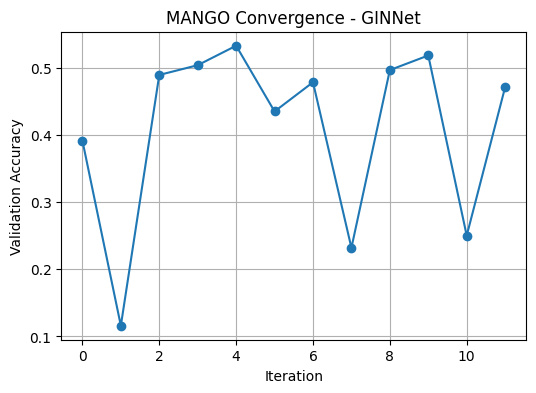


===== MANGO Hyperparameter Tuning for GATNet =====
Best Architecture: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.10806790615546036, 'num_heads': 8, 'aggregation': 'mean'}

[MANGO] Initial random trials = 2 / Total trials = 10

Params: lr=0.005, weight_decay=0.0005, batch_size=64, grad_clip_norm=1.0, class_weights_type=inverse_sqrt_freq
Epoch 01: TrainLoss=2.3077, ValLoss=2.2742, TrainAcc=0.2886, ValAcc=0.3949
Epoch 02: TrainLoss=2.0576, ValLoss=2.0952, TrainAcc=0.3723, ValAcc=0.4058
Epoch 03: TrainLoss=1.9918, ValLoss=2.0503, TrainAcc=0.3825, ValAcc=0.4565
Epoch 04: TrainLoss=1.9378, ValLoss=2.0556, TrainAcc=0.4176, ValAcc=0.3913
Epoch 05: TrainLoss=1.8845, ValLoss=2.0785, TrainAcc=0.4266, ValAcc=0.4203
Epoch 06: TrainLoss=1.8537, ValLoss=2.0518, TrainAcc=0.4253, ValAcc=0.4493
Epoch 07: TrainLoss=1.8638, ValLoss=2.0641, TrainAcc=0.4202, ValAcc=0.4420
Epoch 08: TrainLoss=1.8060, ValLoss=2.1288, TrainAcc=0.4183, ValAcc=0.4493
Epoch 09: TrainLoss=1.8046, ValLoss=2.0966, TrainAcc=0.

  0%|          | 0/10 [00:00<?, ?it/s]


Params: lr=0.0005, weight_decay=0.001, batch_size=32, grad_clip_norm=0.5, class_weights_type=none
Epoch 01: TrainLoss=2.3881, ValLoss=2.5126, TrainAcc=0.2241, ValAcc=0.2754
Epoch 02: TrainLoss=2.0565, ValLoss=2.6654, TrainAcc=0.2803, ValAcc=0.3116
Epoch 03: TrainLoss=1.9250, ValLoss=2.6676, TrainAcc=0.3186, ValAcc=0.3297
Epoch 04: TrainLoss=1.8679, ValLoss=2.6334, TrainAcc=0.3346, ValAcc=0.3587
Epoch 05: TrainLoss=1.8211, ValLoss=2.6009, TrainAcc=0.3333, ValAcc=0.3623
Epoch 06: TrainLoss=1.7907, ValLoss=2.5928, TrainAcc=0.3736, ValAcc=0.3659
Epoch 07: TrainLoss=1.7578, ValLoss=2.5475, TrainAcc=0.3729, ValAcc=0.4058
Epoch 08: TrainLoss=1.7342, ValLoss=2.5534, TrainAcc=0.3863, ValAcc=0.3986
Epoch 09: TrainLoss=1.7393, ValLoss=2.5211, TrainAcc=0.3889, ValAcc=0.4094
Epoch 10: TrainLoss=1.7404, ValLoss=2.5243, TrainAcc=0.3736, ValAcc=0.4058

Params: lr=0.005, weight_decay=0.0005, batch_size=16, grad_clip_norm=0.0, class_weights_type=inverse_sqrt_freq
Epoch 01: TrainLoss=2.5673, ValLoss=2.5

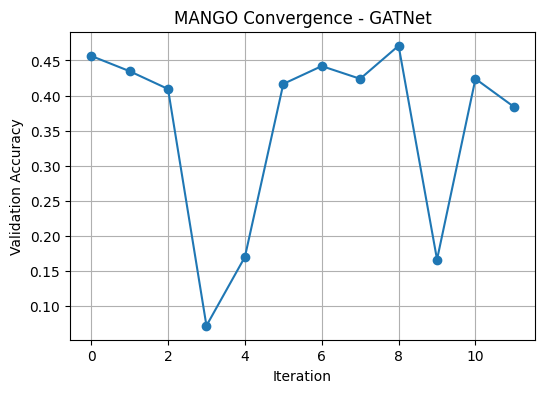


===== MANGO Hyperparameter Tuning for DiffPoolNet =====
Best Architecture: {'hidden_dim': 32, 'assign_dim': 4, 'embed_dim': 64}

[MANGO] Initial random trials = 2 / Total trials = 10

Params: lr=0.005, weight_decay=0.001, batch_size=32, grad_clip_norm=0.0, class_weights_type=inverse_freq
Epoch 01: TrainLoss=2.5660, ValLoss=2.5648, TrainAcc=0.1609, ValAcc=0.0181
Epoch 02: TrainLoss=2.5650, ValLoss=2.5649, TrainAcc=0.1092, ValAcc=0.0362
Epoch 03: TrainLoss=2.5650, ValLoss=2.5649, TrainAcc=0.1239, ValAcc=0.0036
Epoch 04: TrainLoss=2.5649, ValLoss=2.5649, TrainAcc=0.1328, ValAcc=0.2500
Epoch 05: TrainLoss=2.5649, ValLoss=2.5649, TrainAcc=0.1252, ValAcc=0.0036
Epoch 06: TrainLoss=2.5649, ValLoss=2.5649, TrainAcc=0.1060, ValAcc=0.0725
Epoch 07: TrainLoss=2.5649, ValLoss=2.5649, TrainAcc=0.1130, ValAcc=0.0725
Epoch 08: TrainLoss=2.5649, ValLoss=2.5649, TrainAcc=0.1130, ValAcc=0.0725
Epoch 09: TrainLoss=2.5649, ValLoss=2.5649, TrainAcc=0.1213, ValAcc=0.0725
Epoch 10: TrainLoss=2.5649, ValLoss

  0%|          | 0/10 [00:00<?, ?it/s]


Params: lr=0.001, weight_decay=0.001, batch_size=64, grad_clip_norm=0.0, class_weights_type=inverse_sqrt_freq
Epoch 01: TrainLoss=2.5936, ValLoss=2.5820, TrainAcc=0.0089, ValAcc=0.0036
Epoch 02: TrainLoss=2.5804, ValLoss=2.5732, TrainAcc=0.0223, ValAcc=0.0652
Epoch 03: TrainLoss=2.5720, ValLoss=2.5687, TrainAcc=0.0639, ValAcc=0.0688
Epoch 04: TrainLoss=2.5683, ValLoss=2.5667, TrainAcc=0.0766, ValAcc=0.0688
Epoch 05: TrainLoss=2.5664, ValLoss=2.5658, TrainAcc=0.0779, ValAcc=0.0688
Epoch 06: TrainLoss=2.5656, ValLoss=2.5654, TrainAcc=0.0779, ValAcc=0.0688
Epoch 07: TrainLoss=2.5652, ValLoss=2.5651, TrainAcc=0.0779, ValAcc=0.0688
Epoch 08: TrainLoss=2.5650, ValLoss=2.5650, TrainAcc=0.0779, ValAcc=0.0688
Epoch 09: TrainLoss=2.5650, ValLoss=2.5650, TrainAcc=0.0779, ValAcc=0.0688
Epoch 10: TrainLoss=2.5649, ValLoss=2.5650, TrainAcc=0.0779, ValAcc=0.0688

Params: lr=0.001, weight_decay=0.0005, batch_size=16, grad_clip_norm=0.5, class_weights_type=inverse_sqrt_freq
Epoch 01: TrainLoss=2.4409,

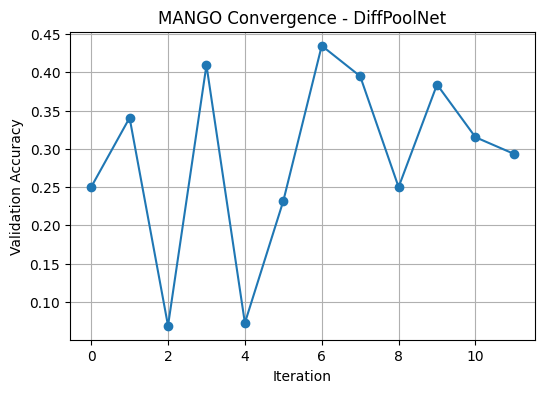

In [ ]:
# Define the MANGO search space
MANGO_SPACE = {
    'lr': [0.0005, 0.001, 0.005],
    'weight_decay': [1e-5, 5e-4, 1e-3],
    'batch_size': [16, 32, 64],
    'grad_clip_norm': [0.0, 0.5, 1.0, 5.0],
    'class_weights_type': ['none', 'inverse_freq', 'inverse_sqrt_freq']
}

# GIN model
best_hparams_gin = run_mango_tuning(GINNet, best_arch_gin, train_dataset, MANGO_SPACE, short_epochs=10)
#print("Best MANGO hyperparameters (GIN):", best_hparams_gin)
# GAT model
best_hparams_gat = run_mango_tuning(GATNet, best_arch_gat, train_dataset, MANGO_SPACE, short_epochs=10)
#print("Best MANGO hyperparameters (GAT):", best_hparams_gat)
# DiffPool model
best_hparams_diff = run_mango_tuning(DiffPoolNet, best_arch_diff, train_dataset, MANGO_SPACE, short_epochs=10)
#print("Best MANGO hyperparameters (DiffPool):", best_hparams_diff)

**Final Training & Reporting**  
Train the chosen architecture with tuned hyperparameters on the **full training set** (no 85/15 split here) and evaluate on the **exact provided test set**. Then produce:
- AUC-ROC (macro)
- AUC-PR (macro)
- Misclassification percentage (misclassified / total * 100)
- Plots for ROC and PR per class


In [ ]:
def final_train_and_report(model_cls, arch_config, best_hparams,
                           device=device, epochs=50):
    """
    Final full training + validation + test evaluation with the best architecture and hyperparameters.
    Compute final metrics (Accuracy, AUC-ROC, AUC-PR, Misclassification %).
    Uses:
      - train_model()    → returns model + training history
      - evaluate_metrics_collect() → returns dict of metrics (acc/loss/cm)
    Inputs:
      model_cls:      class of GNN model (GINNet, GATNet, DiffPoolNet)
      arch_config:    dict of architecture config (from BANANAS)
      best_hparams:   dict of best hyperparameters (from Mango)
      device:         'cuda' or 'cpu'
      epochs:         number of training epochs
    Returns:
      model: trained model
      history: dict containing curves
      test_metrics: dict with accuracy, loss, confusion matrix
    """

    lr = best_hparams['lr']
    wd = best_hparams['weight_decay']
    bs = best_hparams['batch_size']

    # Prepare full data loaders
    train_loader = GraphDataLoader(train_subset, batch_size=bs, shuffle=True)
    val_loader   = GraphDataLoader(val_subset, batch_size=bs, shuffle=False)
    test_loader  = GraphDataLoader(test_dataset, batch_size=bs, shuffle=False)

    # Prepare model
    in_feats = train_graphs[0].ndata['feat'].shape[1]
    arch_cfg_clean = clean_arch_config(arch_config)

    model = _build_model_from_cls(model_cls, arch_cfg_clean, in_feats, num_classes, device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    print(f"\n[Final Training] {model_cls.__name__}")
    print("Best Architecture:", arch_cfg_clean)
    print("Best hyperparameters:", best_hparams)

    # --- full training ---
    # Train with best architecture and hyperparameters
    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        num_epochs=epochs
    )

    print("\n>>> Final training completed.")
    print(f"\n========Results for {model_cls.__name__}========")
    print(f"Best Validation Accuracy: {max(history['val_acc']):.4f}")

    # --- evaluation on test set ---
    print("\nEvaluating on TEST set ...")
    test_metrics, probs, labels = evaluate_metrics_collect(model, test_loader, device)

    print("\nFinal Test Metrics:")
    # Display test_metrics as a DataFrame for better readability
    metrics_df = pd.DataFrame([test_metrics])
    display(metrics_df)

    return model, test_metrics, probs, labels

In [ ]:
# Run final training
gin_best_hparams, _ = best_hparams_gin # Unpack the tuple
gin_model, gin_metrics, gin_probs, gin_labels = final_train_and_report(GINNet, best_arch_gin, gin_best_hparams, epochs=50)

gat_best_hparams, _ = best_hparams_gat # Unpack the tuple
gat_model, gat_metrics, gat_probs, gat_labels = final_train_and_report(GATNet, best_arch_gat, gat_best_hparams, epochs=50)

diff_best_hparams, _ = best_hparams_diff # Unpack the tuple
diff_model, diff_metrics, diff_probs, diff_labels = final_train_and_report(DiffPoolNet, best_arch_diff, diff_best_hparams, epochs=50)


[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 64, 'class_weights_type': 'none', 'grad_clip_norm': 1.0, 'lr': 0.005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.5165, ValLoss=3.0535, TrainAcc=0.2331, ValAcc=0.3007
Epoch 02: TrainLoss=2.3132, ValLoss=2.3163, TrainAcc=0.2407, ValAcc=0.2645
Epoch 03: TrainLoss=2.2368, ValLoss=2.3754, TrainAcc=0.2708, ValAcc=0.2717
Epoch 04: TrainLoss=2.0866, ValLoss=2.1347, TrainAcc=0.3212, ValAcc=0.2536
Epoch 05: TrainLoss=2.0482, ValLoss=2.2034, TrainAcc=0.2861, ValAcc=0.3297
Epoch 06: TrainLoss=2.0355, ValLoss=2.2034, TrainAcc=0.3193, ValAcc=0.2754
Epoch 07: TrainLoss=1.9964, ValLoss=2.2032, TrainAcc=0.2688, ValAcc=0.3261
Epoch 08: TrainLoss=1.9150, ValLoss=2.0790, TrainAcc=0.3289, ValAcc=0.2754
Epoch 09: TrainLoss=1.9038, ValLoss=2.2470, TrainAcc=0.3487, ValAcc=0.2609
Epoch 10: TrainLoss=1.9054, ValLoss=2.0916, TrainAcc=0.334

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,2.305615,0.275058,NaN,0.241545,72.494172



[Final Training] GATNet
Best Architecture: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.10806790615546036, 'num_heads': 8, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 64, 'class_weights_type': 'inverse_sqrt_freq', 'grad_clip_norm': 1.0, 'lr': 0.005, 'weight_decay': 1e-05}
Epoch 01: TrainLoss=2.5256, ValLoss=2.3551, TrainAcc=0.1137, ValAcc=0.2572
Epoch 02: TrainLoss=2.3073, ValLoss=2.1852, TrainAcc=0.2835, ValAcc=0.3406
Epoch 03: TrainLoss=2.1864, ValLoss=2.1203, TrainAcc=0.2765, ValAcc=0.3370
Epoch 04: TrainLoss=2.1069, ValLoss=2.1344, TrainAcc=0.3033, ValAcc=0.2935
Epoch 05: TrainLoss=2.0413, ValLoss=2.2536, TrainAcc=0.2995, ValAcc=0.2826
Epoch 06: TrainLoss=2.0867, ValLoss=2.1869, TrainAcc=0.2886, ValAcc=0.3116
Epoch 07: TrainLoss=1.9922, ValLoss=2.1794, TrainAcc=0.2957, ValAcc=0.3333
Epoch 08: TrainLoss=2.0181, ValLoss=2.1920, TrainAcc=0.3046, ValAcc=0.3116
Epoch 09: TrainLoss=1.9128, ValLoss=2.0980, TrainAcc=0.3455, ValAcc=0.3514
Epoch 10: TrainLoss=1.8782, Val

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.916991,0.321678,NaN,0.253382,67.832168



[Final Training] DiffPoolNet
Best Architecture: {'hidden_dim': 32, 'assign_dim': 4, 'embed_dim': 64}
Best hyperparameters: {'batch_size': 32, 'class_weights_type': 'inverse_sqrt_freq', 'grad_clip_norm': 5.0, 'lr': 0.001, 'weight_decay': 0.001}
Epoch 01: TrainLoss=2.5668, ValLoss=2.5505, TrainAcc=0.0888, ValAcc=0.1268
Epoch 02: TrainLoss=2.5447, ValLoss=2.5349, TrainAcc=0.1277, ValAcc=0.2138
Epoch 03: TrainLoss=2.5427, ValLoss=2.5137, TrainAcc=0.2312, ValAcc=0.2681
Epoch 04: TrainLoss=2.5174, ValLoss=2.4972, TrainAcc=0.2650, ValAcc=0.2935
Epoch 05: TrainLoss=2.4814, ValLoss=2.4619, TrainAcc=0.2867, ValAcc=0.2935
Epoch 06: TrainLoss=2.4463, ValLoss=2.4112, TrainAcc=0.3001, ValAcc=0.3043
Epoch 07: TrainLoss=2.4170, ValLoss=2.3754, TrainAcc=0.2905, ValAcc=0.2935
Epoch 08: TrainLoss=2.3767, ValLoss=2.3214, TrainAcc=0.3072, ValAcc=0.3007
Epoch 09: TrainLoss=2.3343, ValLoss=2.2887, TrainAcc=0.3001, ValAcc=0.2971
Epoch 10: TrainLoss=2.2931, ValLoss=2.2516, TrainAcc=0.2880, ValAcc=0.3188
Epoch

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.820944,0.389277,NaN,0.28005,61.072261


To compare the performance of the GIN, GAT, and DiffPool models, I'll create a pandas DataFrame that displays their key metrics: AUC-ROC, AUC-PR, Misclassification Percentage, and Accuracy.

In [ ]:
import pandas as pd

# 1. Create a dictionary for each model
model_performance = [
    {
        'Model': 'GIN',
        'AUC-ROC': gin_metrics['auc_roc'],
        'AUC-PR': gin_metrics['auc_pr'],
        'Misclassification Percentage': gin_metrics['misclassification_pct'],
        'Accuracy': gin_metrics['accuracy']
    },
    {
        'Model': 'GAT',
        'AUC-ROC': gat_metrics['auc_roc'],
        'AUC-PR': gat_metrics['auc_pr'],
        'Misclassification Percentage': gat_metrics['misclassification_pct'],
        'Accuracy': gat_metrics['accuracy']
    },
    {
        'Model': 'DiffPool',
        'AUC-ROC': diff_metrics['auc_roc'],
        'AUC-PR': diff_metrics['auc_pr'],
        'Misclassification Percentage': diff_metrics['misclassification_pct'],
        'Accuracy': diff_metrics['accuracy']
    }
]

# 2. Create a pandas DataFrame from this list of dictionaries.
df_performance = pd.DataFrame(model_performance)

# 3. Set the 'Model' column as the index of the DataFrame.
df_performance.set_index('Model', inplace=True)

# 4. Display the DataFrame
print("\n--- Model Performance Comparison ---")
display(df_performance)


--- Model Performance Comparison ---


,AUC-ROC,AUC-PR,Misclassification Percentage,Accuracy
Model,,,,
GIN,NaN,0.241545,72.494172,0.275058
GAT,NaN,0.253382,67.832168,0.321678
DiffPool,NaN,0.280050,61.072261,0.389277


**Final Visualization**  
This function plots **ROC** and **Precision–Recall** curves **for each class separately** using the predictions of a single multiclass model. It helps visualize how well the model distinguishes each individual class.


In [ ]:
# Plot AUC-ROC and AUC-PR (per model)
def plot_per_class_roc_pr(probs, labels, model_name="Model"):
    """Plot per-class ROC and Precision-Recall curves side-by-side."""
    n_classes = probs.shape[1]
    y_true = label_binarize(labels, classes=np.arange(n_classes))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Create a figure with 2 subplots side-by-side

    # ROC curves on the first subplot
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
        axes[0].plot(fpr, tpr, label=f"Class {i}")
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_title(f"AUC-ROC Curves — {model_name}")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(fontsize=8)
    axes[0].grid(True)

    # PR curves on the second subplot
    for i in range(n_classes):
        prec, rec, _ = precision_recall_curve(y_true[:, i], probs[:, i])
        axes[1].plot(rec, prec, label=f"Class {i}")
    axes[1].set_title(f"AUC-PR Curves — {model_name}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    axes[1].grid(True)

    plt.tight_layout() # Adjust layout to prevent overlapping elements
    plt.show()

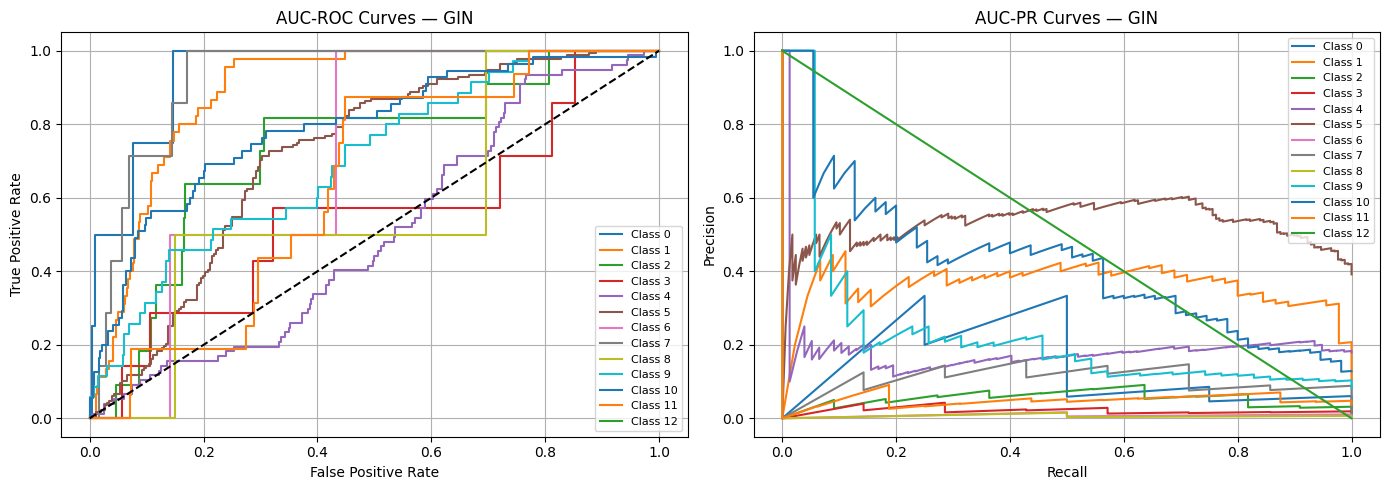

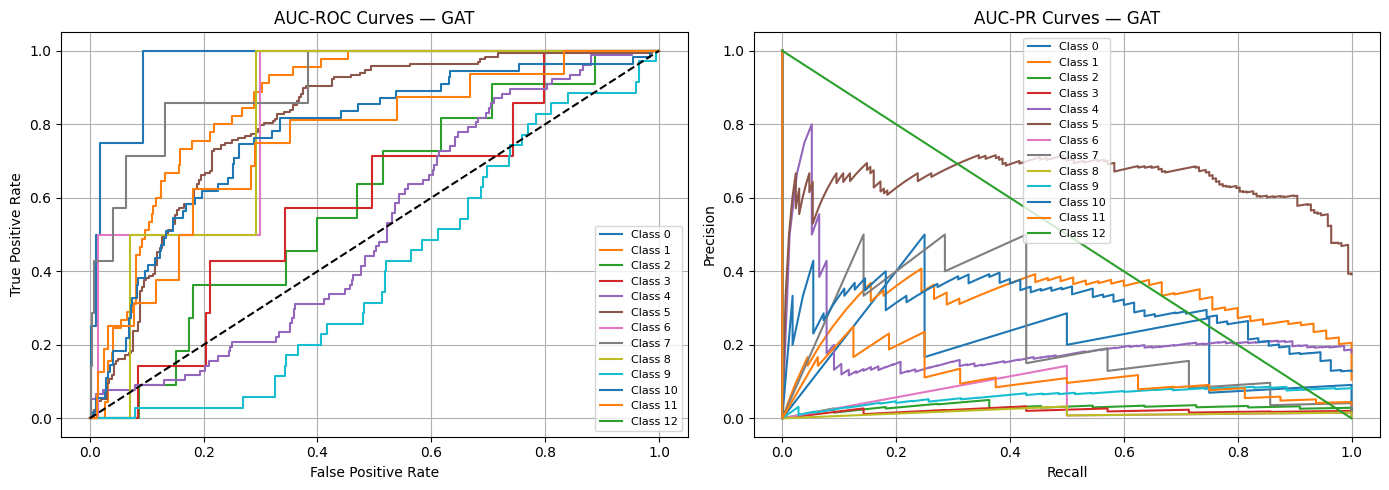

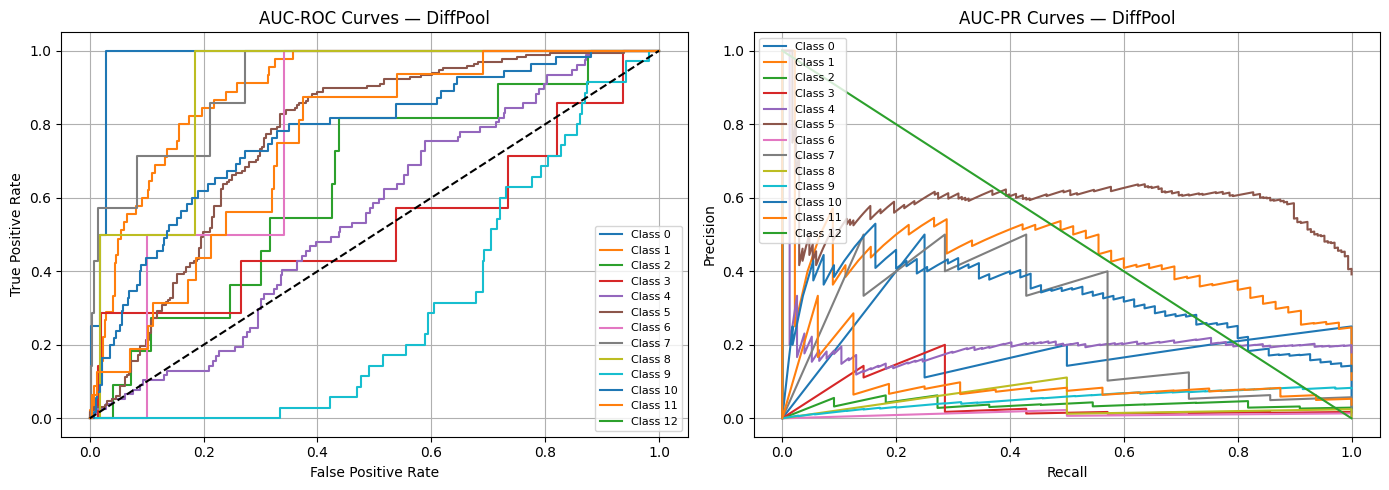

In [ ]:
# plotting AUC-ROC and AUC-PR curves for each model
plot_per_class_roc_pr(gin_probs, gin_labels, "GIN")
plot_per_class_roc_pr(gat_probs, gat_labels, "GAT")
plot_per_class_roc_pr(diff_probs, diff_labels, "DiffPool")

**Model Comparison: ROC and PR**

This section evaluates GIN, GAT, and DiffPool using the same test dataset to ensure a fair comparison.   

`plot_multi_model_macro_roc_pr` function computes and plots **macro-averaged ROC** and **Precision–Recall** curves for **multiple models**, allowing a high-level comparison of their overall multiclass performance.


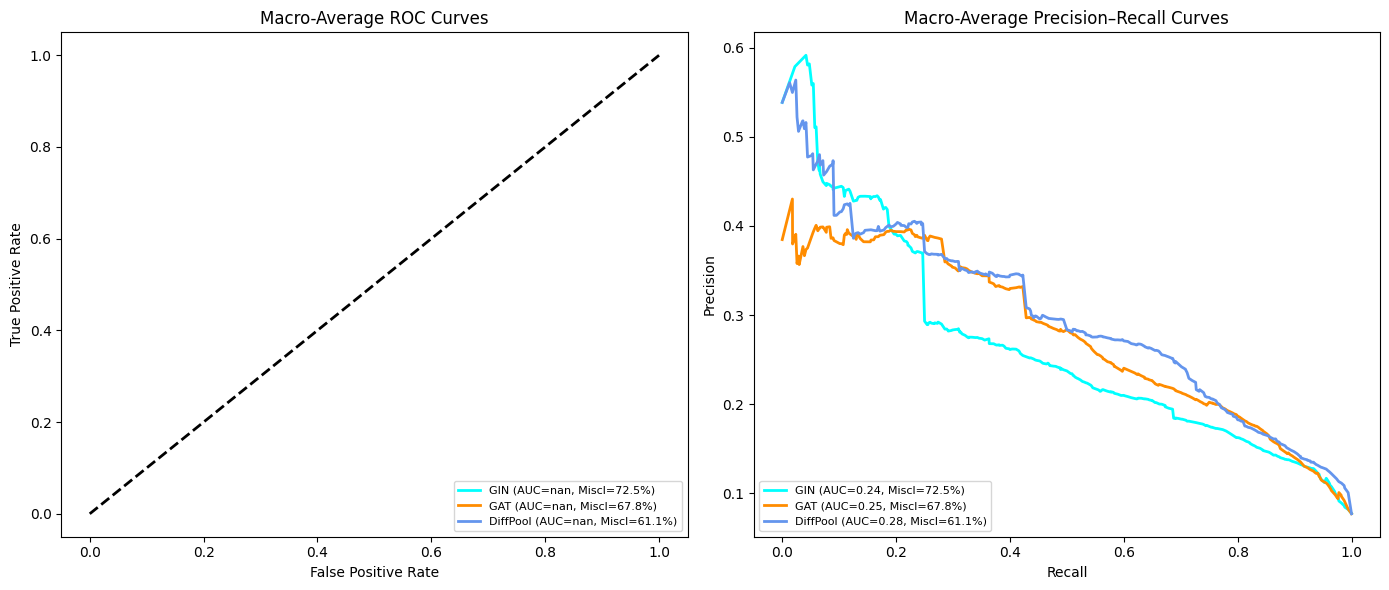

,AUC-ROC (Macro),AUC-PR (Macro),Misclassification %
Model,,,
GIN,NaN,0.242,72.494
GAT,NaN,0.253,67.832
DiffPool,NaN,0.280,61.072


In [ ]:
# ---------- Helper Functions ----------
def plot_multi_model_macro_roc_pr(model_results, num_classes, class_names):
    """
    Plot macro-average ROC & PR curves for multiple models
    and display Misclassification Percentage in the legends.

    model_results: dict -> { 'ModelName': (logits, labels) }
    num_classes: int, number of classes
    class_names: list of str, names of classes
    """

    plt.figure(figsize=(14, 6))
    lw = 2
    colors = itertools.cycle(['aqua', 'darkorange', 'cornflowerblue',
                              'red', 'green', 'purple', 'brown', 'pink',
                              'gray', 'olive', 'cyan', 'magenta', 'yellow'])

    # ---------------- ROC (Macro Average) ---------------- #
    plt.subplot(1, 2, 1)
    for model_name, (logits, labels) in model_results.items():

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        labels_np = labels.cpu().numpy()

        # Compute Misclassification %
        accuracy = (preds == labels_np).mean()
        misclass_percent = 100 * (1 - accuracy)

        # Binarize
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        # ROC per class
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Interpolation (macro-average)
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(num_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= num_classes

        macro_auc = auc(all_fpr, mean_tpr)

        plt.plot(all_fpr, mean_tpr, color=next(colors), lw=lw,
                 label=f'{model_name} (AUC={macro_auc:.2f}, Miscl={misclass_percent:.1f}%)')

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.title("Macro-Average ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8, loc="lower right")

    # ---------------- PR (Macro Average) ---------------- #
    plt.subplot(1, 2, 2)
    colors = itertools.cycle(['aqua', 'darkorange', 'cornflowerblue',
                              'red', 'green', 'purple', 'brown', 'pink',
                              'gray', 'olive', 'cyan', 'magenta', 'yellow'])

    for model_name, (logits, labels) in model_results.items():

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        labels_np = labels.cpu().numpy()

        # Compute Misclassification %
        accuracy = (preds == labels_np).mean()
        misclass_percent = 100 * (1 - accuracy)

        # Binarize
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        precision, recall = {}, {}
        for i in range(num_classes):
            precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])

        all_recall = np.unique(np.concatenate([recall[i] for i in range(num_classes)]))
        mean_precision = np.zeros_like(all_recall)
        for i in range(num_classes):
            sorted_idx = np.argsort(recall[i])
            mean_precision += np.interp(all_recall, recall[i][sorted_idx], precision[i][sorted_idx])
        mean_precision /= num_classes

        macro_pr_auc = average_precision_score(y_true_bin, probs, average='macro')

        plt.plot(all_recall, mean_precision, lw=lw, color=next(colors),
                 label=f'{model_name} (AUC={macro_pr_auc:.2f}, Miscl={misclass_percent:.1f}%)')

    plt.title("Macro-Average Precision–Recall Curves")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(fontsize=8, loc="lower left")

    plt.tight_layout()
    plt.show()



def compute_auc_scores_multi(model_results, num_classes):
    """
    Compute macro AUC-ROC, AUC-PR, and Misclassification Percentage for each model.
    """
    auc_scores = {}

    for model_name, (logits, labels) in model_results.items():

        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        preds = probs.argmax(axis=1)
        labels_np = labels.cpu().numpy()

        # ---- Misclassification % ----
        accuracy = (preds == labels_np).mean()
        miscl_percent = 100 * (1 - accuracy)

        # ---- Prepare for AUC ----
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        try:
            roc_auc = roc_auc_score(y_true_bin, probs, average='macro')
        except ValueError:
            roc_auc = float('nan')

        try:
            pr_auc = average_precision_score(y_true_bin, probs, average='macro')
        except ValueError:
            pr_auc = float('nan')

        auc_scores[model_name] = {
            "AUC-ROC (Macro)": float(roc_auc),
            "AUC-PR (Macro)": float(pr_auc),
            "Misclassification %": float(miscl_percent)
        }

    return auc_scores


# ---------- Run Evaluation ---------- #
# Assuming model_results, num_classes, and class_names are defined from previous cells.

model_results = {
    'GIN': (gin_probs, gin_labels),
    'GAT': (gat_probs, gat_labels),
    'DiffPool': (diff_probs, diff_labels)
}

# Plot multi-class AUC-ROC and AUC-PR curves (Macro Average)
# Ensure num_classes and class_names are available
if 'num_classes' in globals() and 'class_names' in globals():
     plot_multi_model_macro_roc_pr(model_results, num_classes, class_names)
else:
     print("num_classes or class_names not defined. Skipping plotting.")

# Compute macro AUC and Misclassification
if 'num_classes' in globals():
    auc_scores = compute_auc_scores_multi(model_results, num_classes)

    # ---------- Combine Results into Table ---------- #
    summary_data = []
    for model_name, metrics in auc_scores.items():
        summary_data.append({
            'Model': model_name,
            'AUC-ROC (Macro)': float(metrics['AUC-ROC (Macro)']),
            'AUC-PR (Macro)': float(metrics['AUC-PR (Macro)']),
            'Misclassification %': float(metrics['Misclassification %'])
        })

    auc_df = pd.DataFrame(summary_data).set_index('Model')

    # Display summary tables
    display(auc_df.round(3))

In [ ]:
from sklearn.model_selection import KFold

def kfold_cross_validate(
        model_cls,
        arch_config,
        best_hparams,
        dataset,
        num_classes,
        device=device,
        k=5,
        epochs=20,
    ):
    """
    K-fold cross validation for DGL GNN models.
    Returns list of accuracies for all folds.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold = 1
    fold_accuracies = []

    print(f"\n===== {k}-Fold Cross Validation =====")

    for train_idx, val_idx in kf.split(range(len(dataset))):

        print(f"\n---- Fold {fold}/{k} ----")

        train_subset = torch.utils.data.Subset(dataset, train_idx)
        val_subset   = torch.utils.data.Subset(dataset, val_idx)

        arch_cfg_clean = clean_arch_config(arch_config)

        # no test set inside CV, eval = val set
        model, test_metrics, probs, labels = final_train_and_report(
            model_cls=model_cls,
            arch_config=arch_cfg_clean,
            best_hparams=best_hparams,
            device=device,
            epochs=epochs
        )

        acc = test_metrics['accuracy']
        fold_accuracies.append(acc)
        fold += 1

    print("\nFinal Test Metrics:")
    # Display test_metrics as a DataFrame for better readability
    metrics_df = pd.DataFrame([test_metrics])
    display(metrics_df)

    print(f"\n=== K-Fold Mean Accuracy: {np.mean(fold_accuracies):.4f}")
    print(f"Accuracies per fold: {fold_accuracies}")

    return fold_accuracies


In [ ]:
kfold_cross_validate(GINNet, best_arch_gin, gin_best_hparams, train_graphs, num_classes)
kfold_cross_validate(GATNet, best_arch_gat, gat_best_hparams, train_graphs, num_classes)
kfold_cross_validate(DiffPoolNet, best_arch_diff, diff_best_hparams, train_graphs, num_classes)


===== 5-Fold Cross Validation =====

---- Fold 1/5 ----

[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 64, 'class_weights_type': 'none', 'grad_clip_norm': 1.0, 'lr': 0.005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.5362, ValLoss=2.6185, TrainAcc=0.1814, ValAcc=0.2319
Epoch 02: TrainLoss=2.3606, ValLoss=4.4561, TrainAcc=0.2190, ValAcc=0.1522
Epoch 03: TrainLoss=2.3385, ValLoss=3.0378, TrainAcc=0.2331, ValAcc=0.2609
Epoch 04: TrainLoss=2.2055, ValLoss=2.2268, TrainAcc=0.2216, ValAcc=0.2500
Epoch 05: TrainLoss=2.1144, ValLoss=2.1857, TrainAcc=0.2708, ValAcc=0.2609
Epoch 06: TrainLoss=2.0692, ValLoss=2.2193, TrainAcc=0.2989, ValAcc=0.2464
Epoch 07: TrainLoss=1.9864, ValLoss=2.1156, TrainAcc=0.2861, ValAcc=0.3514
Epoch 08: TrainLoss=1.9776, ValLoss=2.3191, TrainAcc=0.3123, ValAcc=0.2899
Epoch 09: TrainLoss=1.9486, ValLoss=2.1179, TrainAcc=0.3333, ValAcc=0.3406
E

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,2.143685,0.275058,NaN,0.228334,72.494172



---- Fold 2/5 ----

[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 64, 'class_weights_type': 'none', 'grad_clip_norm': 1.0, 'lr': 0.005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.5036, ValLoss=3.2898, TrainAcc=0.1501, ValAcc=0.2355
Epoch 02: TrainLoss=2.2935, ValLoss=2.2328, TrainAcc=0.2663, ValAcc=0.2826
Epoch 03: TrainLoss=2.2536, ValLoss=2.2208, TrainAcc=0.2791, ValAcc=0.2826
Epoch 04: TrainLoss=2.1429, ValLoss=2.1096, TrainAcc=0.3027, ValAcc=0.3080
Epoch 05: TrainLoss=2.0581, ValLoss=2.2868, TrainAcc=0.2995, ValAcc=0.1558
Epoch 06: TrainLoss=1.9534, ValLoss=3.3597, TrainAcc=0.3557, ValAcc=0.0797
Epoch 07: TrainLoss=1.9815, ValLoss=2.5773, TrainAcc=0.3665, ValAcc=0.2500
Epoch 08: TrainLoss=1.9077, ValLoss=2.0793, TrainAcc=0.3161, ValAcc=0.3913
Epoch 09: TrainLoss=1.9275, ValLoss=2.2247, TrainAcc=0.3787, ValAcc=0.2681
Epoch 10: TrainLoss=1.9207, ValLoss=2.

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.91733,0.331002,NaN,0.251082,66.899767



---- Fold 3/5 ----

[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.10860454884560528, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 64, 'class_weights_type': 'none', 'grad_clip_norm': 1.0, 'lr': 0.005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.5311, ValLoss=3.6282, TrainAcc=0.1858, ValAcc=0.3116
Epoch 02: TrainLoss=2.4007, ValLoss=2.4413, TrainAcc=0.1807, ValAcc=0.1884
Epoch 03: TrainLoss=2.2889, ValLoss=2.3867, TrainAcc=0.2637, ValAcc=0.3080
Epoch 04: TrainLoss=2.1986, ValLoss=2.1341, TrainAcc=0.2810, ValAcc=0.2790
Epoch 05: TrainLoss=2.1084, ValLoss=2.4509, TrainAcc=0.2752, ValAcc=0.2609
Epoch 06: TrainLoss=2.1363, ValLoss=2.3586, TrainAcc=0.2618, ValAcc=0.2826
Epoch 07: TrainLoss=2.1048, ValLoss=2.1926, TrainAcc=0.3072, ValAcc=0.2101
Epoch 08: TrainLoss=1.9722, ValLoss=2.0993, TrainAcc=0.3123, ValAcc=0.2899
Epoch 09: TrainLoss=1.9433, ValLoss=3.0694, TrainAcc=0.3365, ValAcc=0.1051
Epoch 10: TrainLoss=1.9125, ValLoss=2.

...

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.899842,0.410256,NaN,0.264708,58.974359



Final Test Metrics:


,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.899842,0.410256,NaN,0.264708,58.974359



=== K-Fold Mean Accuracy: 0.3669
Accuracies per fold: [0.331002331002331, 0.3613053613053613, 0.3706293706293706, 0.3613053613053613, 0.41025641025641024]


[0.331002331002331,
 0.3613053613053613,
 0.3706293706293706,
 0.3613053613053613,
 0.41025641025641024]

## Analyze Error Patterns
The `plot_confusion_matrix` function will calculate, normalize, and display the confusion matrix using a heatmap to analyze error patterns and identify common misclassifications.



**Confusion Matrix**  
This function will generate and visualize the confusion matrices for each model (GIN, GAT, and DiffPool) using their respective true labels, predicted labels derived from probabilities, and the global `class_names`.



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(true_labels, predicted_labels, class_names, model_name="Model"):
    """
    Calculates, normalizes, and plots the confusion matrix as a heatmap.
    """
    cm = confusion_matrix(true_labels, predicted_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

print("Libraries imported and plot_confusion_matrix function defined.")

Libraries imported and plot_confusion_matrix function defined.


Generating confusion matrices for GIN, GAT, and DiffPool models...


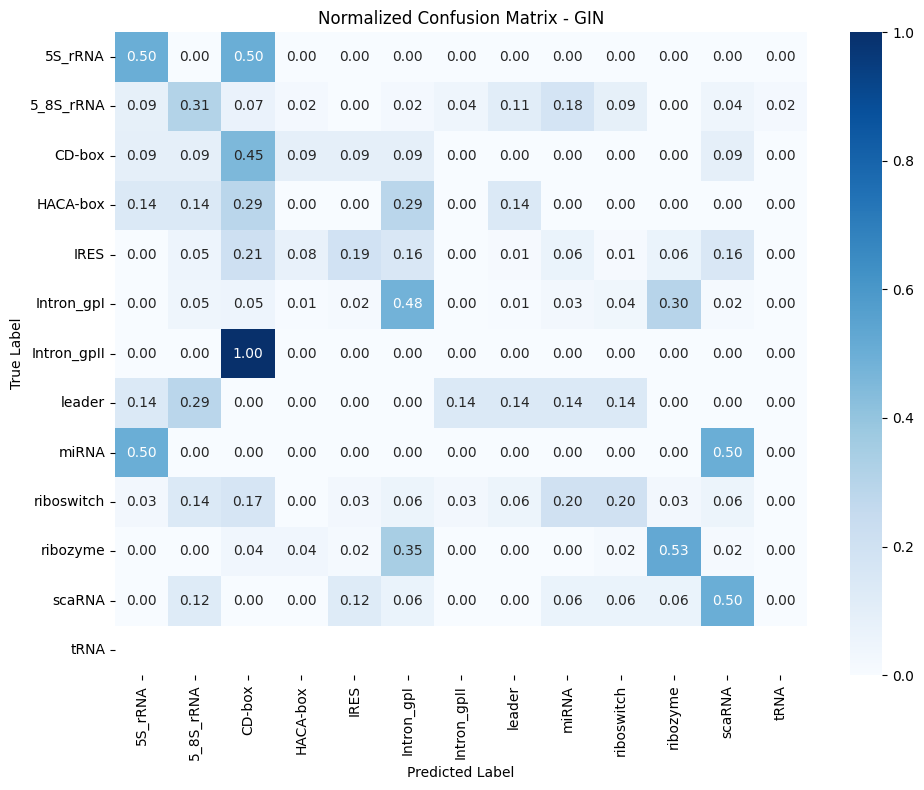

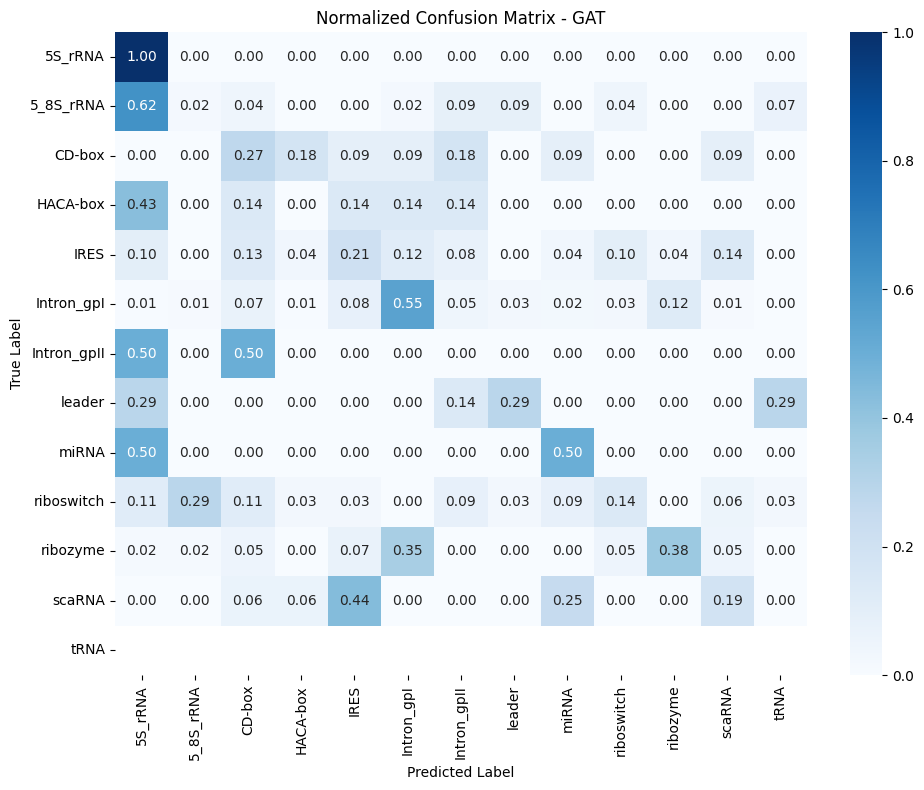

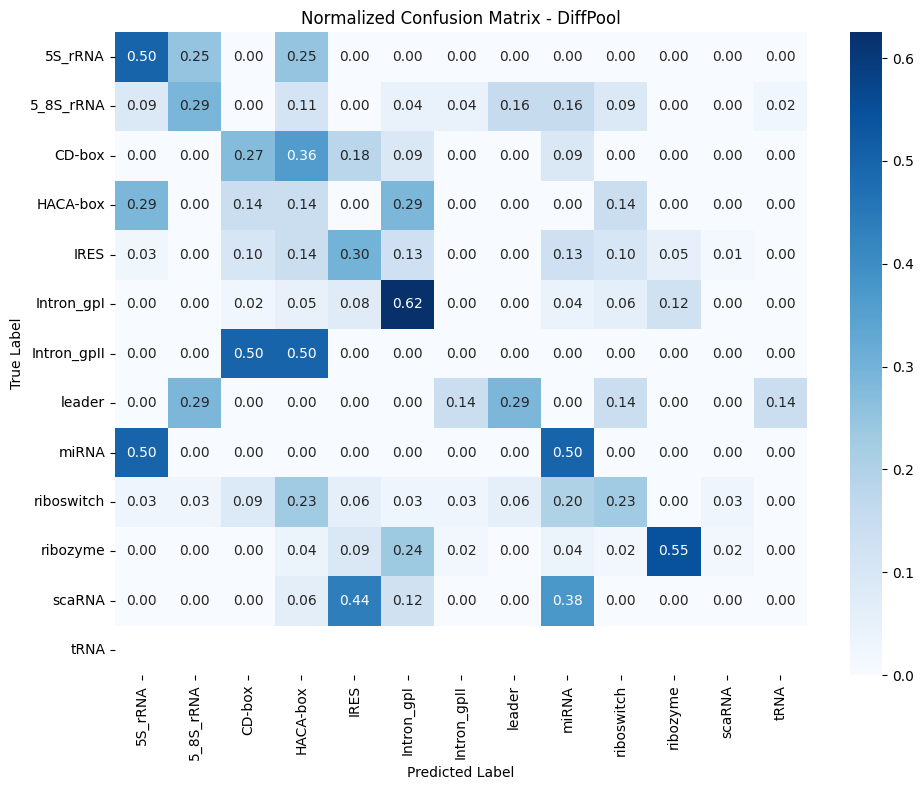

Confusion matrices generated successfully.


In [ ]:
print("Generating confusion matrices for GIN, GAT, and DiffPool models...")

# GIN Model
gin_predicted_labels = torch.argmax(gin_probs, axis=1).cpu().numpy()
plot_confusion_matrix(gin_labels.cpu().numpy(), gin_predicted_labels, class_names, "GIN")

# GAT Model
gat_predicted_labels = torch.argmax(gat_probs, axis=1).cpu().numpy()
plot_confusion_matrix(gat_labels.cpu().numpy(), gat_predicted_labels, class_names, "GAT")

# DiffPool Model
diff_predicted_labels = torch.argmax(diff_probs, axis=1).cpu().numpy()
plot_confusion_matrix(diff_labels.cpu().numpy(), diff_predicted_labels, class_names, "DiffPool")

print("Confusion matrices generated successfully.")